<h1>Obligation-Guided Counterexample Validation of LLM-Generated Safety Specifications</h1>

This notebook implements a small research prototype for validating LLM-generated safety specifications in a biosecurity access-control setting. The core idea is to decompose natural-language requirements into traceable safety obligations, represent candidate specifications in a restricted logical DSL, and validate them using obligation coverage, behavioral agreement, metamorphic relations, SMT-guided counterexample search, and counterexample-guided repair. The experiment is intentionally small but quantitative, suitable for a take-home research assignment.


This stage installs and imports the packages needed for the experiment. The notebook only depends on standard scientific Python packages plus z3-solver, so it should run in a lightweight Jupyter environment without project-specific setup.


In [1]:
%pip install z3-solver pandas numpy matplotlib


Looking in indexes: http://mirrors.aliyun.com/pypi/simple/
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import json
import itertools
import copy
from dataclasses import dataclass
from typing import Any, Dict, List, Tuple, Optional
from z3 import Solver, Int, Bool, And, Or, Not, BoolVal, IntVal, sat, is_true
from IPython.display import display

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 80)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True


This stage defines the finite input space for biosecurity access control. Each input is split into user, record, and context fields, and each requirement receives a reproducible sample of 2000 inputs for scalable behavioral testing.


In [ ]:
roles = ["PI", "researcher", "trainee", "external"]
clearance_values = list(range(6))
risk_values = list(range(6))
bool_values = [False, True]
full_inputs = []

for role, clearance, training_completed, approval_active, approval_expired, supervised_by_pi in itertools.product(roles, clearance_values, bool_values, bool_values, bool_values, bool_values):
    user = {"role": role, "clearance": clearance, "training_completed": training_completed, "approval_active": approval_active, "approval_expired": approval_expired, "supervised_by_pi": supervised_by_pi}
    for risk_level, anonymized, sensitive in itertools.product(risk_values, bool_values, bool_values):
        record = {"risk_level": risk_level, "anonymized": anonymized, "sensitive": sensitive}
        for emergency, logged in itertools.product(bool_values, bool_values):
            full_inputs.append({"user": user.copy(), "record": record.copy(), "context": {"emergency": emergency, "logged": logged}})
boundary_pool = [env for env in full_inputs if env["user"]["clearance"] in [0, 1, 4, 5] or env["record"]["risk_level"] in [0, 1, 4, 5] or env["user"]["role"] in ["external", "trainee"]]

def sample_inputs_for_requirement(requirement_id, n=2000):
    local_rng = np.random.default_rng(SEED + int(requirement_id.replace("R", "")))
    boundary_count = int(n * 0.45)
    random_count = n - boundary_count
    boundary_indices = local_rng.choice(len(boundary_pool), size=boundary_count, replace=False)
    random_indices = local_rng.choice(len(full_inputs), size=random_count, replace=False)
    sampled = [copy.deepcopy(boundary_pool[i]) for i in boundary_indices] + [copy.deepcopy(full_inputs[i]) for i in random_indices]
    local_rng.shuffle(sampled)
    return sampled
sampled_inputs = {f"R{i:02d}": sample_inputs_for_requirement(f"R{i:02d}") for i in range(1, 11)}
print("Full input space size:", len(full_inputs))
print("Sampled inputs per requirement:", len(sampled_inputs["R01"]))


Full input space size: 36864
Sampled inputs per requirement: 2000


This stage defines a restricted logical DSL for candidate safety specifications. Specifications are JSON-like abstract syntax trees over Boolean connectives, comparisons, field references, and constants, with helper functions for evaluation, readable rendering, and structural coverage analysis.


In [ ]:
def FIELD(path):
    return {"op": "FIELD", "path": path.split(".") if isinstance(path, str) else list(path)}

def CONST(value):
    return {"op": "CONST", "value": value}

def P(op, left, right):
    left_expr = FIELD(left) if isinstance(left, str) else left
    right_expr = FIELD(right) if isinstance(right, str) and "." in right else CONST(right) if not isinstance(right, dict) else right
    return {"op": op, "args": [left_expr, right_expr]}

def AND_(*args):
    flat = []
    for arg in args:
        flat.extend(arg.get("args", [])) if isinstance(arg, dict) and arg.get("op") == "AND" else flat.append(arg)
    return {"op": "AND", "args": flat}

def OR_(*args):
    flat = []
    for arg in args:
        flat.extend(arg.get("args", [])) if isinstance(arg, dict) and arg.get("op") == "OR" else flat.append(arg)
    return {"op": "OR", "args": flat}

def NOT_(arg):
    return {"op": "NOT", "arg": arg}

def get_field_value(path, env):
    value = env
    for part in path:
        value = value[part]
    return value

def eval_expr(expr, env):
    op = expr.get("op")
    if op == "FIELD":
        return get_field_value(expr["path"], env)
    if op == "CONST":
        return expr["value"]
    if op == "AND":
        return all(eval_expr(arg, env) for arg in expr.get("args", []))
    if op == "OR":
        return any(eval_expr(arg, env) for arg in expr.get("args", []))
    if op == "NOT":
        return not eval_expr(expr["arg"], env)
    if op in ["EQ", "NEQ", "GE", "GT", "LE", "LT"]:
        left, right = [eval_expr(arg, env) for arg in expr.get("args", [])]
        return {"EQ": left == right, "NEQ": left != right, "GE": left >= right, "GT": left > right, "LE": left <= right, "LT": left < right}[op]
    raise ValueError(f"Unsupported expression: {expr}")

def expr_to_string(expr):
    op = expr.get("op")
    if op == "FIELD":
        return ".".join(expr["path"])
    if op == "CONST":
        return json.dumps(expr["value"])
    if op == "NOT":
        return f"NOT({expr_to_string(expr['arg'])})"
    if op in ["AND", "OR"]:
        return "(" + f" {op} ".join(expr_to_string(arg) for arg in expr.get("args", [])) + ")"
    if op in ["EQ", "NEQ", "GE", "GT", "LE", "LT"]:
        symbol = {"EQ": "=", "NEQ": "!=", "GE": ">=", "GT": ">", "LE": "<=", "LT": "<"}[op]
        return f"{expr_to_string(expr['args'][0])} {symbol} {expr_to_string(expr['args'][1])}"
    return json.dumps(expr)

def collect_fields(expr):
    fields = set()
    op = expr.get("op")
    if op == "FIELD":
        fields.add(".".join(expr["path"]))
    for key in ["args"]:
        for arg in expr.get(key, []):
            fields.update(collect_fields(arg))
    if op == "NOT":
        fields.update(collect_fields(expr["arg"]))
    return fields

def collect_atomic_predicates(expr):
    op = expr.get("op")
    if op in ["EQ", "NEQ", "GE", "GT", "LE", "LT"]:
        return [expr]
    atoms = []
    for arg in expr.get("args", []):
        atoms.extend(collect_atomic_predicates(arg))
    if op == "NOT":
        atoms.extend(collect_atomic_predicates(expr["arg"]))
    return atoms

def canonical_term(expr):
    if expr.get("op") == "FIELD":
        return ("FIELD", ".".join(expr["path"]))
    if expr.get("op") == "CONST":
        return ("CONST", json.dumps(expr["value"], sort_keys=True))
    return ("EXPR", expr_to_string(expr))

def canonical_predicate(expr):
    op = expr.get("op")
    if op not in ["EQ", "NEQ", "GE", "GT", "LE", "LT"]:
        return ("COMPLEX", expr_to_string(expr))
    left, right = expr["args"]
    if op in ["EQ", "NEQ"]:
        a, b = sorted([canonical_term(left), canonical_term(right)])
        return (op, a, b)
    return (op, canonical_term(left), canonical_term(right))


This stage decomposes natural-language biosecurity access-control requirements into traceable safety obligations. Each requirement includes a natural-language statement, obligation predicates with severities, and a gold specification used as the behavioral reference.


In [ ]:
def O(identifier, name, severity, predicate):
    return {"id": identifier, "name": name, "severity": severity, "predicate": predicate}

def make_requirement(identifier, natural_language, obligations, gold_spec=None):
    return {"id": identifier, "natural_language": natural_language, "obligations": obligations, "gold_spec": gold_spec if gold_spec is not None else AND_(*[o["predicate"] for o in obligations])}

requirements = []
requirements.append(make_requirement("R01", "Access to controlled biological records requires clearance at least equal to the record risk, completed training, and active approval.", [O("R01-O1", "clearance at least risk", "high", P("GE", "user.clearance", "record.risk_level")), O("R01-O2", "training completed", "high", P("EQ", "user.training_completed", True)), O("R01-O3", "approval active", "medium", P("EQ", "user.approval_active", True))]))

requirements.append(make_requirement("R02", "Routine internal research access excludes external collaborators and requires training and active approval.", [O("R02-O1", "external collaborators excluded", "high", P("NEQ", "user.role", "external")), O("R02-O2", "training completed", "high", P("EQ", "user.training_completed", True)), O("R02-O3", "approval active", "medium", P("EQ", "user.approval_active", True))]))

requirements.append(make_requirement("R03", "Approved access is valid only when approval is active, not expired, auditable, and the requester has completed training.", [O("R03-O1", "approval active", "high", P("EQ", "user.approval_active", True)), O("R03-O2", "approval not expired", "high", P("EQ", "user.approval_expired", False)), O("R03-O3", "access logged", "medium", P("EQ", "context.logged", True)), O("R03-O4", "training completed", "medium", P("EQ", "user.training_completed", True))]))

requirements.append(make_requirement("R04", "Expired approvals must not authorize access even when clearance is sufficient, and all valid access must be logged.", [O("R04-O1", "approval active", "medium", P("EQ", "user.approval_active", True)), O("R04-O2", "approval not expired", "high", P("EQ", "user.approval_expired", False)), O("R04-O3", "clearance at least risk", "high", P("GE", "user.clearance", "record.risk_level")), O("R04-O4", "access logged", "medium", P("EQ", "context.logged", True))]))

requirements.append(make_requirement("R05", "External collaborators may access only anonymized, non-sensitive, low-to-moderate-risk records through logged access.", [O("R05-O1", "external role", "low", P("EQ", "user.role", "external")), O("R05-O2", "record anonymized", "high", P("EQ", "record.anonymized", True)), O("R05-O3", "record not sensitive", "high", P("EQ", "record.sensitive", False)), O("R05-O4", "risk at most moderate", "medium", P("LE", "record.risk_level", 2)), O("R05-O5", "access logged", "medium", P("EQ", "context.logged", True))]))

requirements.append(make_requirement("R06", "Emergency access is allowed only during an emergency, must be logged, must not use expired approval, and requires PI status or sufficient clearance.", [O("R06-O1", "emergency context", "medium", P("EQ", "context.emergency", True)), O("R06-O2", "access logged", "high", P("EQ", "context.logged", True)), O("R06-O3", "approval not expired", "high", P("EQ", "user.approval_expired", False)), O("R06-O4", "PI or sufficient clearance", "high", OR_(P("EQ", "user.role", "PI"), P("GE", "user.clearance", "record.risk_level")))], AND_(P("EQ", "context.emergency", True), P("EQ", "context.logged", True), P("EQ", "user.approval_expired", False), OR_(P("EQ", "user.role", "PI"), P("GE", "user.clearance", "record.risk_level")))))

requirements.append(make_requirement("R07", "High-risk biological records are accessible only to PIs with sufficient clearance, completed training, and logged access.", [O("R07-O1", "high risk record", "medium", P("GE", "record.risk_level", 4)), O("R07-O2", "PI only", "high", P("EQ", "user.role", "PI")), O("R07-O3", "clearance at least risk", "high", P("GE", "user.clearance", "record.risk_level")), O("R07-O4", "training completed", "medium", P("EQ", "user.training_completed", True)), O("R07-O5", "access logged", "medium", P("EQ", "context.logged", True))]))

requirements.append(make_requirement("R08", "Trainees may access records only when supervised by a PI, trained, sufficiently cleared, and actively approved.", [O("R08-O1", "trainee role", "low", P("EQ", "user.role", "trainee")), O("R08-O2", "supervised by PI", "high", P("EQ", "user.supervised_by_pi", True)), O("R08-O3", "training completed", "high", P("EQ", "user.training_completed", True)), O("R08-O4", "clearance at least risk", "medium", P("GE", "user.clearance", "record.risk_level")), O("R08-O5", "approval active", "medium", P("EQ", "user.approval_active", True))]))

requirements.append(make_requirement("R09", "Sensitive records require PI or researcher status, sufficient clearance, completed training, active approval, and logged access.", [O("R09-O1", "sensitive record", "medium", P("EQ", "record.sensitive", True)), O("R09-O2", "PI or researcher role", "high", OR_(P("EQ", "user.role", "PI"), P("EQ", "user.role", "researcher"))), O("R09-O3", "clearance at least risk", "high", P("GE", "user.clearance", "record.risk_level")), O("R09-O4", "training completed", "medium", P("EQ", "user.training_completed", True)), O("R09-O5", "access logged", "medium", P("EQ", "context.logged", True))], AND_(P("EQ", "record.sensitive", True), OR_(P("EQ", "user.role", "PI"), P("EQ", "user.role", "researcher")), P("GE", "user.clearance", "record.risk_level"), P("EQ", "user.training_completed", True), P("EQ", "context.logged", True))))

low_risk_path = AND_(P("LE", "record.risk_level", 1), P("EQ", "record.sensitive", False), P("EQ", "context.logged", True))

standard_path = AND_(P("GE", "user.clearance", "record.risk_level"), P("EQ", "user.training_completed", True), P("EQ", "user.approval_active", True), P("EQ", "user.approval_expired", False), P("EQ", "context.logged", True))

requirements.append(make_requirement("R10", "Low-risk non-sensitive records have a logged exception path; otherwise standard clearance, training, active approval, non-expiration, and logging are required.", [O("R10-O1", "low risk exception", "low", low_risk_path), O("R10-O2", "clearance at least risk", "high", P("GE", "user.clearance", "record.risk_level")), O("R10-O3", "training completed", "high", P("EQ", "user.training_completed", True)), O("R10-O4", "approval valid", "medium", AND_(P("EQ", "user.approval_active", True), P("EQ", "user.approval_expired", False))), O("R10-O5", "access logged", "medium", P("EQ", "context.logged", True))], OR_(low_risk_path, standard_path)))

requirements_by_id = {r["id"]: r for r in requirements}

requirement_summary_df = pd.DataFrame([{"requirement_id": r["id"], "obligation_count": len(r["obligations"]), "gold_spec": expr_to_string(r["gold_spec"])} for r in requirements])

display(requirement_summary_df)


,requirement_id,obligation_count,gold_spec
0,R01,3,(user.clearance >= record.risk_level AND user.training_completed = true AND user.approval_active = true)
1,R02,3,"(user.role != ""external"" AND user.training_completed = true AND user.approval_active = true)"
2,R03,4,(user.approval_active = true AND user.approval_expired = false AND context.logged = true AND user.training_completed...
3,R04,4,(user.approval_active = true AND user.approval_expired = false AND user.clearance >= record.risk_level AND context.l...
4,R05,5,"(user.role = ""external"" AND record.anonymized = true AND record.sensitive = false AND record.risk_level <= 2 AND con..."
5,R06,4,"(context.emergency = true AND context.logged = true AND user.approval_expired = false AND (user.role = ""PI"" OR user...."
6,R07,5,"(record.risk_level >= 4 AND user.role = ""PI"" AND user.clearance >= record.risk_level AND user.training_completed = t..."
7,R08,5,"(user.role = ""trainee"" AND user.supervised_by_pi = true AND user.training_completed = true AND user.clearance >= rec..."
8,R09,5,"(record.sensitive = true AND (user.role = ""PI"" OR user.role = ""researcher"") AND user.clearance >= record.risk_level ..."
9,R10,5,((record.risk_level <= 1 AND record.sensitive = false AND context.logged = true) OR (user.clearance >= record.risk_l...


This stage constructs LLM-like candidate specifications without calling an external model. The candidates simulate plausible generation failures such as missing obligations, wrong comparators, wrong Boolean connectives, unnecessary restrictions, and omitted emergency logging.


In [ ]:
def requirement_spec_from_obligations(requirement, obligation_indices=None):
    selected = requirement["obligations"] if obligation_indices is None else [requirement["obligations"][i] for i in obligation_indices]
    return AND_(*[copy.deepcopy(o["predicate"]) for o in selected])

def mutate_first_comparator(expr):
    mutated = copy.deepcopy(expr)
    replacements = {"GE": "GT", "GT": "GE", "LE": "LT", "LT": "LE", "EQ": "NEQ", "NEQ": "EQ"}
    done = False
    def visit(node):
        nonlocal done
        if done:
            return
        op = node.get("op")
        if op in replacements:
            node["op"] = replacements[op]
            done = True
            return
        for arg in node.get("args", []):
            visit(arg)
        if op == "NOT":
            visit(node["arg"])
    visit(mutated)
    return mutated

def replace_top_and_with_or(expr):
    mutated = copy.deepcopy(expr)
    if mutated.get("op") == "AND":
        mutated["op"] = "OR"
        return mutated
    return OR_(*collect_atomic_predicates(mutated)[:2])

def remove_atoms_by_canonical(expr, canonical_targets):
    def visit(node):
        op = node.get("op")
        if op in ["EQ", "NEQ", "GE", "GT", "LE", "LT"]:
            return None if canonical_predicate(node) in canonical_targets else copy.deepcopy(node)
        if op in ["AND", "OR"]:
            kept = [visit(arg) for arg in node.get("args", [])]
            kept = [arg for arg in kept if arg is not None]
            if not kept:
                return None
            return kept[0] if len(kept) == 1 else {"op": op, "args": kept}
        if op == "NOT":
            child = visit(node["arg"])
            return None if child is None else NOT_(child)
        return copy.deepcopy(node)
    result = visit(expr)
    
    return result if result is not None else CONST(True)

def add_extra_pi(spec):
    return AND_(copy.deepcopy(spec), P("EQ", "user.role", "PI"))

def drop_first_logging_or_expiration(spec):
    targets = {canonical_predicate(P("EQ", "context.logged", True)), canonical_predicate(P("EQ", "user.approval_expired", False))}
    return remove_atoms_by_canonical(spec, targets)

candidates = []

for requirement in requirements:
    rid = requirement["id"]
    high_indices = [i for i, o in enumerate(requirement["obligations"]) if o["severity"] == "high"]
    missing_index = high_indices[0] if high_indices else 0
    keep_indices = [i for i in range(len(requirement["obligations"])) if i != missing_index]
    candidates.append({"id": f"{rid}-C1", "requirement_id": rid, "name": "missing key obligation", "spec": requirement_spec_from_obligations(requirement, keep_indices), "intended_fault": "missing_obligation"})
    candidates.append({"id": f"{rid}-C2", "requirement_id": rid, "name": "wrong comparator or polarity", "spec": mutate_first_comparator(requirement["gold_spec"]), "intended_fault": "wrong_comparator"})
    if rid == "R06":
        spec, fault, name = drop_first_logging_or_expiration(requirement["gold_spec"]), "missing_emergency_logging", "omits emergency logging"
    elif rid in ["R02", "R05", "R09", "R10"]:
        spec, fault, name = replace_top_and_with_or(requirement["gold_spec"]), "wrong_boolean_connective", "over-permissive Boolean connective"
    else:
        spec, fault, name = add_extra_pi(requirement["gold_spec"]), "extra_restriction", "unnecessary PI-only restriction"
    candidates.append({"id": f"{rid}-C3", "requirement_id": rid, "name": name, "spec": spec, "intended_fault": fault})
    
candidate_distribution_df = pd.DataFrame(candidates).groupby("intended_fault").size().reset_index(name="count")

print("Candidate specs total:", len(candidates))

display(candidate_distribution_df)


Candidate specs total: 30


,intended_fault,count
0,extra_restriction,5
1,missing_emergency_logging,1
2,missing_obligation,10
3,wrong_boolean_connective,4
4,wrong_comparator,10


This stage generates controlled mutants from gold specifications. Mutants provide known injected faults, which makes it possible to evaluate whether the validation strategy detects specification defects that should be discoverable.


In [ ]:
def expressions_differ(spec_a, spec_b, inputs):
    return any(eval_expr(spec_a, env) != eval_expr(spec_b, env) for env in inputs)

def drop_one_obligation_mutant(requirement, offset=0):
    keep = [i for i in range(len(requirement["obligations"])) if i != offset % len(requirement["obligations"])]
    return requirement_spec_from_obligations(requirement, keep)

def negate_first_boolean_condition(expr):
    mutated = copy.deepcopy(expr)
    done = False
    def visit(node):
        nonlocal done
        if done:
            return
        op = node.get("op")
        if op in ["EQ", "NEQ"] and node["args"][1].get("op") == "CONST" and isinstance(node["args"][1]["value"], bool):
            node["args"][1]["value"] = not node["args"][1]["value"]
            done = True
            return
        for arg in node.get("args", []):
            visit(arg)
    visit(mutated)
    
    return mutated if done else mutate_first_comparator(expr)

def make_mutation(requirement, mutation_type, offset):
    
    gold = requirement["gold_spec"]
    if mutation_type == "drop_one_obligation":
        return drop_one_obligation_mutant(requirement, offset)
    if mutation_type == "flip_comparator":
        return mutate_first_comparator(gold)
    if mutation_type == "replace_and_with_or":
        return replace_top_and_with_or(gold)
    if mutation_type == "negate_boolean_condition":
        return negate_first_boolean_condition(gold)
    if mutation_type == "add_extra_pi_constraint":
        return add_extra_pi(gold)
    if mutation_type == "drop_logging_or_expiration_if_present":
        return drop_first_logging_or_expiration(gold)
    return drop_one_obligation_mutant(requirement, offset)

mutation_types = ["drop_one_obligation", "flip_comparator", "replace_and_with_or", "negate_boolean_condition", "add_extra_pi_constraint", "drop_logging_or_expiration_if_present"]
mutants = []

for requirement in requirements:
    for index, mutation_type in enumerate(mutation_types):
        spec = make_mutation(requirement, mutation_type, index)
        if not expressions_differ(requirement["gold_spec"], spec, sampled_inputs[requirement["id"]]):
            mutation_type = "drop_one_obligation" if mutation_type != "drop_one_obligation" else "add_extra_pi_constraint"
            spec = make_mutation(requirement, mutation_type, index + 1)
        mutants.append({"id": f"{requirement['id']}-M{index + 1}", "requirement_id": requirement["id"], "mutation_type": mutation_type, "spec": spec})
        
mutation_distribution_df = pd.DataFrame(mutants).groupby("mutation_type").size().reset_index(name="count")
print("Mutants total:", len(mutants))

display(mutation_distribution_df)


Mutants total: 60


,mutation_type,count
0,add_extra_pi_constraint,9
1,drop_logging_or_expiration_if_present,7
2,drop_one_obligation,14
3,flip_comparator,10
4,negate_boolean_condition,10
5,replace_and_with_or,10


This stage implements the obligation coverage oracle. It compares the atomic predicates implied by each requirement obligation with the atomic predicates present in a candidate or mutant specification, producing missing-obligation and high-severity coverage signals.


In [ ]:
def predicate_equivalent_by_string(left, right):
    return canonical_predicate(left) == canonical_predicate(right)

def obligation_atomic_keys(obligation):
    return {canonical_predicate(atom) for atom in collect_atomic_predicates(obligation["predicate"])}

def compute_obligation_coverage(requirement, spec):
    spec_atoms = {canonical_predicate(atom) for atom in collect_atomic_predicates(spec)}
    covered, missing = [], []
    for obligation in requirement["obligations"]:
        atoms = obligation_atomic_keys(obligation)
        covered.append(obligation) if atoms and atoms.issubset(spec_atoms) else missing.append(obligation)
    return {"covered_obligations": [o["id"] for o in covered], "missing_obligations": [o["id"] for o in missing], "missing_obligation_names": [o["name"] for o in missing], "coverage_rate": len(covered) / len(requirement["obligations"]), "missing_high_severity_count": sum(1 for o in missing if o["severity"] == "high")}

def all_spec_items():
    items = []
    for candidate in candidates:
        item = candidate.copy()
        item["kind"] = "candidate"
        items.append(item)
    for mutant in mutants:
        item = mutant.copy()
        item["kind"] = "mutant"
        item["name"] = mutant["mutation_type"]
        item["intended_fault"] = mutant["mutation_type"]
        items.append(item)
    return items

coverage_rows = []

for item in all_spec_items():
    requirement = requirements_by_id[item["requirement_id"]]
    row = {"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": item["kind"], "name": item.get("name"), "fault_type": item.get("intended_fault", item.get("mutation_type"))}
    row.update(compute_obligation_coverage(requirement, item["spec"]))
    coverage_rows.append(row)
    
coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df.head(12))


,item_id,requirement_id,kind,name,fault_type,covered_obligations,missing_obligations,missing_obligation_names,coverage_rate,missing_high_severity_count
0,R01-C1,R01,candidate,missing key obligation,missing_obligation,"[R01-O2, R01-O3]",[R01-O1],[clearance at least risk],0.666667,1
1,R01-C2,R01,candidate,wrong comparator or polarity,wrong_comparator,"[R01-O2, R01-O3]",[R01-O1],[clearance at least risk],0.666667,1
2,R01-C3,R01,candidate,unnecessary PI-only restriction,extra_restriction,"[R01-O1, R01-O2, R01-O3]",[],[],1.000000,0
3,R02-C1,R02,candidate,missing key obligation,missing_obligation,"[R02-O2, R02-O3]",[R02-O1],[external collaborators excluded],0.666667,1
4,R02-C2,R02,candidate,wrong comparator or polarity,wrong_comparator,"[R02-O2, R02-O3]",[R02-O1],[external collaborators excluded],0.666667,1
5,R02-C3,R02,candidate,over-permissive Boolean connective,wrong_boolean_connective,"[R02-O1, R02-O2, R02-O3]",[],[],1.000000,0
6,R03-C1,R03,candidate,missing key obligation,missing_obligation,"[R03-O2, R03-O3, R03-O4]",[R03-O1],[approval active],0.750000,1
7,R03-C2,R03,candidate,wrong comparator or polarity,wrong_comparator,"[R03-O2, R03-O3, R03-O4]",[R03-O1],[approval active],0.750000,1
8,R03-C3,R03,candidate,unnecessary PI-only restriction,extra_restriction,"[R03-O1, R03-O2, R03-O3, R03-O4]",[],[],1.000000,0
9,R04-C1,R04,candidate,missing key obligation,missing_obligation,"[R04-O1, R04-O3, R04-O4]",[R04-O2],[approval not expired],0.750000,1


This stage implements the behavioral agreement oracle. For each specification, it compares allow or deny outputs against the gold specification on the 2000 sampled inputs for the corresponding requirement, distinguishing under-constrained and over-constrained failures.


In [ ]:
def high_severity_obligations_violated(requirement, env):
    return [o["id"] for o in requirement["obligations"] if o["severity"] == "high" and not eval_expr(o["predicate"], env)]

def evaluate_behavior(requirement, spec_item, inputs):
    start = time.perf_counter()
    agreements, under_constrained, over_constrained, high_severity_under = 0, 0, 0, 0
    first_counterexample, time_to_first = None, None
    for env in inputs:
        gold_output = eval_expr(requirement["gold_spec"], env)
        candidate_output = eval_expr(spec_item["spec"], env)
        if gold_output == candidate_output:
            agreements += 1
        else:
            if first_counterexample is None:
                first_counterexample = copy.deepcopy(env)
                time_to_first = time.perf_counter() - start
            if not gold_output and candidate_output:
                under_constrained += 1
                high_severity_under += 1 if high_severity_obligations_violated(requirement, env) else 0
            if gold_output and not candidate_output:
                over_constrained += 1
    total = len(inputs)
    return {"total": total, "agreements": agreements, "disagreements": total - agreements, "agreement_rate": agreements / total, "under_constrained_count": under_constrained, "over_constrained_count": over_constrained, "high_severity_under_constrained_count": high_severity_under, "first_counterexample": first_counterexample, "behavior_time": time.perf_counter() - start, "time_to_first_counterexample": time_to_first}
behavior_rows = []

for item in all_spec_items():
    requirement = requirements_by_id[item["requirement_id"]]
    row = {"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": item["kind"], "fault_type": item.get("intended_fault", item.get("mutation_type"))}
    row.update(evaluate_behavior(requirement, item, sampled_inputs[item["requirement_id"]]))
    behavior_rows.append(row)
    
behavior_df = pd.DataFrame(behavior_rows)

display(behavior_df.head(12))


,item_id,requirement_id,kind,fault_type,total,agreements,disagreements,agreement_rate,under_constrained_count,over_constrained_count,high_severity_under_constrained_count,first_counterexample,behavior_time,time_to_first_counterexample
0,R01-C1,R01,candidate,missing_obligation,2000,1813,187,0.9065,187,0,187,"{'user': {'role': 'researcher', 'clearance': 4, 'training_completed': True, 'approval_active': True, 'approval_expir...",0.009177,0.000043
1,R01-C2,R01,candidate,wrong_comparator,2000,1913,87,0.9565,0,87,0,"{'user': {'role': 'external', 'clearance': 3, 'training_completed': True, 'approval_active': True, 'approval_expired...",0.009023,0.000066
2,R01-C3,R01,candidate,extra_restriction,2000,1781,219,0.8905,0,219,0,"{'user': {'role': 'external', 'clearance': 4, 'training_completed': True, 'approval_active': True, 'approval_expired...",0.009711,0.000025
3,R02-C1,R02,candidate,missing_obligation,2000,1875,125,0.9375,125,0,125,"{'user': {'role': 'external', 'clearance': 3, 'training_completed': True, 'approval_active': True, 'approval_expired...",0.009098,0.000091
4,R02-C2,R02,candidate,wrong_comparator,2000,1494,506,0.7470,125,381,125,"{'user': {'role': 'trainee', 'clearance': 1, 'training_completed': True, 'approval_active': True, 'approval_expired'...",0.009255,0.000028
5,R02-C3,R02,candidate,wrong_boolean_connective,2000,496,1504,0.2480,1504,0,1135,"{'user': {'role': 'external', 'clearance': 0, 'training_completed': False, 'approval_active': True, 'approval_expire...",0.011677,0.000024
6,R03-C1,R03,candidate,missing_obligation,2000,1878,122,0.9390,122,0,122,"{'user': {'role': 'external', 'clearance': 4, 'training_completed': True, 'approval_active': False, 'approval_expire...",0.009268,0.000043
7,R03-C2,R03,candidate,wrong_comparator,2000,1752,248,0.8760,122,126,122,"{'user': {'role': 'external', 'clearance': 4, 'training_completed': True, 'approval_active': False, 'approval_expire...",0.009357,0.000043
8,R03-C3,R03,candidate,extra_restriction,2000,1911,89,0.9555,0,89,0,"{'user': {'role': 'external', 'clearance': 5, 'training_completed': True, 'approval_active': True, 'approval_expired...",0.008805,0.000092
9,R04-C1,R04,candidate,missing_obligation,2000,1837,163,0.9185,163,0,163,"{'user': {'role': 'researcher', 'clearance': 1, 'training_completed': True, 'approval_active': True, 'approval_expir...",0.009432,0.000112


This stage implements metamorphic testing. Each relation perturbs one safety-relevant dimension of an input and checks whether the candidate specification violates a conservative access-control intuition under that perturbation.


In [ ]:
def set_nested(env, section, key, value):
    updated = copy.deepcopy(env)
    updated[section][key] = value
    return updated

def clearance_monotonicity(env):
    return None if env["user"]["clearance"] >= 5 else set_nested(env, "user", "clearance", env["user"]["clearance"] + 1)

def risk_monotonicity(env):
    return None if env["record"]["risk_level"] >= 5 else set_nested(env, "record", "risk_level", env["record"]["risk_level"] + 1)

def expiration_safety(env):
    return None if env["user"]["approval_expired"] else set_nested(env, "user", "approval_expired", True)

def external_anonymization_relaxation(env):
    return None if env["user"]["role"] != "external" or env["record"]["anonymized"] else set_nested(env, "record", "anonymized", True)

def emergency_logging_safety(env):
    return None if not env["context"]["emergency"] or not env["context"]["logged"] else set_nested(env, "context", "logged", False)

metamorphic_relations = {
    "clearance_monotonicity": (clearance_monotonicity, lambda base, follow: base and not follow),
    "risk_monotonicity": (risk_monotonicity, lambda base, follow: (not base) and follow),
    "expiration_safety": (expiration_safety, lambda base, follow: (not base) and follow),
    "external_anonymization_relaxation": (external_anonymization_relaxation, lambda base, follow: base and not follow),
    "emergency_logging_safety": (emergency_logging_safety, lambda base, follow: (not base) and follow),
}

def evaluate_metamorphic(spec_item, base_inputs):
    checked, violations, first_violation, breakdown = 0, 0, None, {}
    for relation_name, (transform, violation_rule) in metamorphic_relations.items():
        relation_checked, relation_violations = 0, 0
        for env in base_inputs:
            follow_env = transform(env)
            if follow_env is None:
                continue
            relation_checked += 1
            checked += 1
            base_output = eval_expr(spec_item["spec"], env)
            follow_output = eval_expr(spec_item["spec"], follow_env)
            if violation_rule(base_output, follow_output):
                relation_violations += 1
                violations += 1
                if first_violation is None:
                    first_violation = {"relation": relation_name, "base_input": copy.deepcopy(env), "follow_up_input": copy.deepcopy(follow_env), "base_output": base_output, "follow_up_output": follow_output}
        breakdown[relation_name] = {"checked": relation_checked, "violations": relation_violations}
    return {"checked_count": checked, "violation_count": violations, "violation_rate": violations / checked if checked else 0.0, "first_violation": first_violation, "relation_breakdown": breakdown}
metamorphic_rows = []

for item in all_spec_items():
    row = {"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": item["kind"], "fault_type": item.get("intended_fault", item.get("mutation_type"))}
    row.update(evaluate_metamorphic(item, sampled_inputs[item["requirement_id"]][:1000]))
    metamorphic_rows.append(row)
    
metamorphic_df = pd.DataFrame(metamorphic_rows)
display(metamorphic_df.head(12))


,item_id,requirement_id,kind,fault_type,checked_count,violation_count,violation_rate,first_violation,relation_breakdown
0,R01-C1,R01,candidate,missing_obligation,2538,0,0.0,None,"{'clearance_monotonicity': {'checked': 833, 'violations': 0}, 'risk_monotonicity': {'checked': 825, 'violations': 0}..."
1,R01-C2,R01,candidate,wrong_comparator,2538,0,0.0,None,"{'clearance_monotonicity': {'checked': 833, 'violations': 0}, 'risk_monotonicity': {'checked': 825, 'violations': 0}..."
2,R01-C3,R01,candidate,extra_restriction,2538,0,0.0,None,"{'clearance_monotonicity': {'checked': 833, 'violations': 0}, 'risk_monotonicity': {'checked': 825, 'violations': 0}..."
3,R02-C1,R02,candidate,missing_obligation,2550,0,0.0,None,"{'clearance_monotonicity': {'checked': 828, 'violations': 0}, 'risk_monotonicity': {'checked': 836, 'violations': 0}..."
4,R02-C2,R02,candidate,wrong_comparator,2550,0,0.0,None,"{'clearance_monotonicity': {'checked': 828, 'violations': 0}, 'risk_monotonicity': {'checked': 836, 'violations': 0}..."
5,R02-C3,R02,candidate,wrong_boolean_connective,2550,0,0.0,None,"{'clearance_monotonicity': {'checked': 828, 'violations': 0}, 'risk_monotonicity': {'checked': 836, 'violations': 0}..."
6,R03-C1,R03,candidate,missing_obligation,2553,0,0.0,None,"{'clearance_monotonicity': {'checked': 829, 'violations': 0}, 'risk_monotonicity': {'checked': 816, 'violations': 0}..."
7,R03-C2,R03,candidate,wrong_comparator,2553,0,0.0,None,"{'clearance_monotonicity': {'checked': 829, 'violations': 0}, 'risk_monotonicity': {'checked': 816, 'violations': 0}..."
8,R03-C3,R03,candidate,extra_restriction,2553,0,0.0,None,"{'clearance_monotonicity': {'checked': 829, 'violations': 0}, 'risk_monotonicity': {'checked': 816, 'violations': 0}..."
9,R04-C1,R04,candidate,missing_obligation,2532,0,0.0,None,"{'clearance_monotonicity': {'checked': 858, 'violations': 0}, 'risk_monotonicity': {'checked': 826, 'violations': 0}..."


This stage implements SMT-guided counterexample search. The DSL is encoded into Z3 over finite-domain variables, and the solver searches for an input on which the gold specification and candidate specification disagree.


In [ ]:
role_to_int = {role: index for index, role in enumerate(roles)}
int_to_role = {index: role for role, index in role_to_int.items()}
z3_field_specs = {"user.role": "role", "user.clearance": "int", "user.training_completed": "bool", "user.approval_active": "bool", "user.approval_expired": "bool", "user.supervised_by_pi": "bool", "record.risk_level": "int", "record.anonymized": "bool", "record.sensitive": "bool", "context.emergency": "bool", "context.logged": "bool"}
def create_z3_vars():
    return {path: Bool(path.replace(".", "_")) if kind == "bool" else Int(path.replace(".", "_")) for path, kind in z3_field_specs.items()}

def z3_const(value):
    if isinstance(value, bool):
        return BoolVal(value)
    if isinstance(value, int):
        return IntVal(value)
    if isinstance(value, str) and value in role_to_int:
        return IntVal(role_to_int[value])
    raise ValueError(f"Unsupported constant for Z3: {value}")

def z3_encode(expr, vars_by_path):
    op = expr.get("op")
    if op == "FIELD":
        return vars_by_path[".".join(expr["path"])]
    if op == "CONST":
        return z3_const(expr["value"])
    if op == "AND":
        args = [z3_encode(arg, vars_by_path) for arg in expr.get("args", [])]
        return And(*args) if args else BoolVal(True)
    if op == "OR":
        args = [z3_encode(arg, vars_by_path) for arg in expr.get("args", [])]
        return Or(*args) if args else BoolVal(False)
    if op == "NOT":
        return Not(z3_encode(expr["arg"], vars_by_path))
    left, right = z3_encode(expr["args"][0], vars_by_path), z3_encode(expr["args"][1], vars_by_path)
    if op == "EQ":
        return left == right
    if op == "NEQ":
        return left != right
    if op == "GE":
        return left >= right
    if op == "GT":
        return left > right
    if op == "LE":
        return left <= right
    if op == "LT":
        return left < right
    raise ValueError(f"Unsupported Z3 expression: {expr}")

def domain_constraints(vars_by_path):
    return [And(vars_by_path["user.role"] >= 0, vars_by_path["user.role"] <= 3), And(vars_by_path["user.clearance"] >= 0, vars_by_path["user.clearance"] <= 5), And(vars_by_path["record.risk_level"] >= 0, vars_by_path["record.risk_level"] <= 5)]

def model_to_env(model, vars_by_path):
    env = {"user": {}, "record": {}, "context": {}}
    for path, var in vars_by_path.items():
        section, key = path.split(".")
        value = model.eval(var, model_completion=True)
        kind = z3_field_specs[path]
        env[section][key] = bool(is_true(value)) if kind == "bool" else int_to_role[value.as_long()] if kind == "role" else value.as_long()
    return env

def find_smt_counterexample(gold_spec, candidate_spec):
    start = time.perf_counter()
    vars_by_path = create_z3_vars()
    solver = Solver()
    solver.add(*domain_constraints(vars_by_path))
    solver.add(z3_encode(gold_spec, vars_by_path) != z3_encode(candidate_spec, vars_by_path))
    result = solver.check()
    elapsed = time.perf_counter() - start
    return (model_to_env(solver.model(), vars_by_path), elapsed) if result == sat else (None, elapsed)

smt_rows = []
for item in all_spec_items():
    requirement = requirements_by_id[item["requirement_id"]]
    counterexample, elapsed = find_smt_counterexample(requirement["gold_spec"], item["spec"])
    smt_rows.append({"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": item["kind"], "fault_type": item.get("intended_fault", item.get("mutation_type")), "has_smt_counterexample": counterexample is not None, "smt_counterexample": counterexample, "smt_time": elapsed})
smt_df = pd.DataFrame(smt_rows)
display(smt_df.head(12))


,item_id,requirement_id,kind,fault_type,has_smt_counterexample,smt_counterexample,smt_time
0,R01-C1,R01,candidate,missing_obligation,True,"{'user': {'role': 'PI', 'clearance': 0, 'training_completed': True, 'approval_active': True, 'approval_expired': Fal...",0.043078
1,R01-C2,R01,candidate,wrong_comparator,True,"{'user': {'role': 'PI', 'clearance': 0, 'training_completed': True, 'approval_active': True, 'approval_expired': Fal...",0.002547
2,R01-C3,R01,candidate,extra_restriction,True,"{'user': {'role': 'researcher', 'clearance': 0, 'training_completed': True, 'approval_active': True, 'approval_expir...",0.002414
3,R02-C1,R02,candidate,missing_obligation,True,"{'user': {'role': 'external', 'clearance': 0, 'training_completed': True, 'approval_active': True, 'approval_expired...",0.002215
4,R02-C2,R02,candidate,wrong_comparator,True,"{'user': {'role': 'external', 'clearance': 0, 'training_completed': True, 'approval_active': True, 'approval_expired...",0.001909
5,R02-C3,R02,candidate,wrong_boolean_connective,True,"{'user': {'role': 'PI', 'clearance': 0, 'training_completed': False, 'approval_active': False, 'approval_expired': F...",0.001930
6,R03-C1,R03,candidate,missing_obligation,True,"{'user': {'role': 'PI', 'clearance': 0, 'training_completed': True, 'approval_active': False, 'approval_expired': Fa...",0.001981
7,R03-C2,R03,candidate,wrong_comparator,True,"{'user': {'role': 'PI', 'clearance': 0, 'training_completed': True, 'approval_active': False, 'approval_expired': Fa...",0.001966
8,R03-C3,R03,candidate,extra_restriction,True,"{'user': {'role': 'researcher', 'clearance': 0, 'training_completed': True, 'approval_active': True, 'approval_expir...",0.002013
9,R04-C1,R04,candidate,missing_obligation,True,"{'user': {'role': 'PI', 'clearance': 0, 'training_completed': False, 'approval_active': True, 'approval_expired': Tr...",0.001943


This stage merges oracle outputs into a risk-weighted review card. The score combines obligation coverage, sampled behavioral agreement, metamorphic consistency, absence of high-severity under-constrained behavior, and SMT consistency.


In [ ]:
def build_review_dataframe(coverage, behavior, metamorphic, smt):
    merged = coverage.merge(behavior, on=["item_id", "requirement_id", "kind", "fault_type"], suffixes=("", "_behavior"))
    merged = merged.merge(metamorphic, on=["item_id", "requirement_id", "kind", "fault_type"], suffixes=("", "_metamorphic"))
    merged = merged.merge(smt, on=["item_id", "requirement_id", "kind", "fault_type"], suffixes=("", "_smt"))
    merged["metamorphic_consistency"] = 1.0 - merged["violation_rate"]
    merged["high_severity_under_safe"] = (merged["high_severity_under_constrained_count"] == 0).astype(float)
    merged["smt_consistency"] = (~merged["has_smt_counterexample"]).astype(float)
    merged["score"] = 25 * merged["coverage_rate"] + 25 * merged["agreement_rate"] + 20 * merged["metamorphic_consistency"] + 20 * merged["high_severity_under_safe"] + 10 * merged["smt_consistency"]
    def assign_risk(row):
        if row["missing_high_severity_count"] > 0 or row["high_severity_under_constrained_count"] > 0:
            return "high"
        if row["disagreements"] > 0 or row["violation_count"] > 0 or row["has_smt_counterexample"]:
            return "medium"
        return "low"
    merged["risk_level"] = merged.apply(assign_risk, axis=1)
    return merged.sort_values(["risk_level", "score"], ascending=[True, True]).reset_index(drop=True)

review_df = build_review_dataframe(coverage_df, behavior_df, metamorphic_df, smt_df)
display(review_df[["item_id", "requirement_id", "kind", "fault_type", "coverage_rate", "agreement_rate", "violation_rate", "has_smt_counterexample", "score", "risk_level", "missing_obligation_names"]].head(15))


,item_id,requirement_id,kind,fault_type,coverage_rate,agreement_rate,violation_rate,has_smt_counterexample,score,risk_level,missing_obligation_names
0,R10-C3,R10,candidate,wrong_boolean_connective,0.0,0.4235,0.000000,True,30.587500,high,"[low risk exception, clearance at least risk, training completed, approval valid, access logged]"
1,R10-M3,R10,mutant,replace_and_with_or,0.0,0.4235,0.000000,True,30.587500,high,"[low risk exception, clearance at least risk, training completed, approval valid, access logged]"
2,R07-M3,R07,mutant,replace_and_with_or,1.0,0.0370,0.006706,True,45.790878,high,[]
3,R08-M3,R08,mutant,replace_and_with_or,1.0,0.0510,0.000000,True,46.275000,high,[]
4,R05-C3,R05,candidate,wrong_boolean_connective,1.0,0.0665,0.000000,True,46.662500,high,[]
5,R05-M3,R05,mutant,replace_and_with_or,1.0,0.0665,0.000000,True,46.662500,high,[]
6,R09-C3,R09,candidate,wrong_boolean_connective,1.0,0.0675,0.000000,True,46.687500,high,[]
7,R09-M3,R09,mutant,replace_and_with_or,1.0,0.0675,0.000000,True,46.687500,high,[]
8,R04-M3,R04,mutant,replace_and_with_or,1.0,0.1200,0.000000,True,48.000000,high,[]
9,R03-M3,R03,mutant,replace_and_with_or,1.0,0.1210,0.000000,True,48.025000,high,[]


This stage simulates counterexample-guided repair without calling a real LLM. Missing obligations are added back into the candidate specification, and recognizable over-constrained patterns are repaired by replacing overly strict candidate logic with the gold reference for this controlled experiment.


In [ ]:
def repair_candidate(candidate, original_review_row):
    requirement = requirements_by_id[candidate["requirement_id"]]
    missing_ids = set(original_review_row["missing_obligations"])
    if missing_ids:
        missing_predicates = [copy.deepcopy(o["predicate"]) for o in requirement["obligations"] if o["id"] in missing_ids]
        return AND_(copy.deepcopy(candidate["spec"]), *missing_predicates), "add_missing_obligations"
    if original_review_row["over_constrained_count"] > 0 and candidate["intended_fault"] in ["extra_restriction", "wrong_comparator"]:
        return copy.deepcopy(requirement["gold_spec"]), "replace_recognized_over_constraint"
    if candidate["intended_fault"] in ["wrong_boolean_connective", "missing_emergency_logging"] and original_review_row["under_constrained_count"] > 0:
        return copy.deepcopy(requirement["gold_spec"]), "replace_recognized_under_constraint"
    return copy.deepcopy(candidate["spec"]), "unchanged"

repaired_specs = []

for candidate in candidates:
    original_row = review_df[review_df["item_id"] == candidate["id"]].iloc[0]
    repaired_spec, repair_action = repair_candidate(candidate, original_row)
    repaired_specs.append({"id": candidate["id"].replace("-C", "-RC"), "original_item_id": candidate["id"], "requirement_id": candidate["requirement_id"], "kind": "repaired_candidate", "name": candidate["name"], "fault_type": candidate["intended_fault"], "repair_action": repair_action, "spec": repaired_spec})
    
def run_oracles_for_items(items):
    
    coverage_rows_local, behavior_rows_local, metamorphic_rows_local, smt_rows_local = [], [], [], []
    
    for item in items:
        requirement = requirements_by_id[item["requirement_id"]]
        coverage_row = {"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": item["kind"], "name": item.get("name"), "fault_type": item.get("fault_type")}
        coverage_row.update(compute_obligation_coverage(requirement, item["spec"]))
        coverage_rows_local.append(coverage_row)
        behavior_row = {"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": item["kind"], "fault_type": item.get("fault_type")}
        behavior_row.update(evaluate_behavior(requirement, item, sampled_inputs[item["requirement_id"]]))
        behavior_rows_local.append(behavior_row)
        metamorphic_row = {"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": item["kind"], "fault_type": item.get("fault_type")}
        metamorphic_row.update(evaluate_metamorphic(item, sampled_inputs[item["requirement_id"]][:1000]))
        metamorphic_rows_local.append(metamorphic_row)
        counterexample, elapsed = find_smt_counterexample(requirement["gold_spec"], item["spec"])
        smt_rows_local.append({"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": item["kind"], "fault_type": item.get("fault_type"), "has_smt_counterexample": counterexample is not None, "smt_counterexample": counterexample, "smt_time": elapsed})
        
    return pd.DataFrame(coverage_rows_local), pd.DataFrame(behavior_rows_local), pd.DataFrame(metamorphic_rows_local), pd.DataFrame(smt_rows_local)

repair_coverage_df, repair_behavior_df, repair_metamorphic_df, repair_smt_df = run_oracles_for_items(repaired_specs)

repaired_review_df = build_review_dataframe(repair_coverage_df, repair_behavior_df, repair_metamorphic_df, repair_smt_df)

repair_rows = []

for repaired in repaired_specs:
    
    original = review_df[review_df["item_id"] == repaired["original_item_id"]].iloc[0]
    fixed = repaired_review_df[repaired_review_df["item_id"] == repaired["id"]].iloc[0]
    repair_rows.append({"original_item_id": repaired["original_item_id"], "repaired_item_id": repaired["id"], "requirement_id": repaired["requirement_id"], "fault_type": repaired["fault_type"], "repair_action": repaired["repair_action"], "score_before": original["score"], "score_after": fixed["score"], "disagreements_before": original["disagreements"], "disagreements_after": fixed["disagreements"], "high_under_before": original["high_severity_under_constrained_count"], "high_under_after": fixed["high_severity_under_constrained_count"], "repair_success": fixed["score"] > original["score"] and fixed["high_severity_under_constrained_count"] == 0, "regression": fixed["disagreements"] > original["disagreements"]})
    
repair_df = pd.DataFrame(repair_rows)

repair_success_rate = repair_df["repair_success"].mean()

regression_rate = repair_df["regression"].mean()

display(repair_df.head(15))

print("Repair success rate:", round(repair_success_rate, 3))
print("Regression rate:", round(regression_rate, 3))


,original_item_id,repaired_item_id,requirement_id,fault_type,repair_action,score_before,score_after,disagreements_before,disagreements_after,high_under_before,high_under_after,repair_success,regression
0,R01-C1,R01-RC1,R01,missing_obligation,add_missing_obligations,59.329167,100.0000,187,0,187,0,True,False
1,R01-C2,R01-RC2,R01,wrong_comparator,add_missing_obligations,80.579167,88.9125,87,87,0,0,True,False
2,R01-C3,R01-RC3,R01,extra_restriction,replace_recognized_over_constraint,87.262500,100.0000,219,0,0,0,True,False
3,R02-C1,R02-RC1,R02,missing_obligation,add_missing_obligations,60.104167,100.0000,125,0,125,0,True,False
4,R02-C2,R02-RC2,R02,wrong_comparator,add_missing_obligations,55.341667,85.2375,506,381,125,0,True,False
5,R02-C3,R02-RC3,R02,wrong_boolean_connective,replace_recognized_under_constraint,51.200000,100.0000,1504,0,1135,0,True,False
6,R03-C1,R03-RC1,R03,missing_obligation,add_missing_obligations,62.225000,100.0000,122,0,122,0,True,False
7,R03-C2,R03-RC2,R03,wrong_comparator,add_missing_obligations,60.650000,88.4250,248,126,122,0,True,False
8,R03-C3,R03-RC3,R03,extra_restriction,replace_recognized_over_constraint,88.887500,100.0000,89,0,0,0,True,False
9,R04-C1,R04-RC1,R04,missing_obligation,add_missing_obligations,61.712500,100.0000,163,0,163,0,True,False


Repair success rate: 0.967
Regression rate: 0.033


This stage produces the main experimental result tables. The method-level comparison uses increasingly strong validation strategies, from a small manual fixed test set to the full multi-oracle validator.


In [ ]:
def fixed_boundary_inputs_for_requirement(requirement_id):
    cases = [
        {"user": {"role": "PI", "clearance": 5, "training_completed": True, "approval_active": True, "approval_expired": False, "supervised_by_pi": True}, "record": {"risk_level": 5, "anonymized": True, "sensitive": True}, "context": {"emergency": False, "logged": True}},
        {"user": {"role": "researcher", "clearance": 3, "training_completed": True, "approval_active": True, "approval_expired": False, "supervised_by_pi": False}, "record": {"risk_level": 3, "anonymized": False, "sensitive": False}, "context": {"emergency": False, "logged": True}},
        {"user": {"role": "trainee", "clearance": 2, "training_completed": True, "approval_active": True, "approval_expired": False, "supervised_by_pi": True}, "record": {"risk_level": 2, "anonymized": True, "sensitive": False}, "context": {"emergency": False, "logged": True}},
        {"user": {"role": "external", "clearance": 1, "training_completed": True, "approval_active": True, "approval_expired": False, "supervised_by_pi": False}, "record": {"risk_level": 1, "anonymized": True, "sensitive": False}, "context": {"emergency": False, "logged": True}},
        {"user": {"role": "researcher", "clearance": 0, "training_completed": False, "approval_active": False, "approval_expired": True, "supervised_by_pi": False}, "record": {"risk_level": 5, "anonymized": False, "sensitive": True}, "context": {"emergency": True, "logged": False}},
        {"user": {"role": "PI", "clearance": 4, "training_completed": True, "approval_active": True, "approval_expired": False, "supervised_by_pi": True}, "record": {"risk_level": 4, "anonymized": False, "sensitive": True}, "context": {"emergency": True, "logged": True}},
    ]
    return [copy.deepcopy(case) for case in cases]

def random_inputs_for_requirement(requirement_id, n=300):
    local_rng = np.random.default_rng(SEED + 100 + int(requirement_id.replace("R", "")))
    indices = local_rng.choice(len(full_inputs), size=n, replace=False)
    return [copy.deepcopy(full_inputs[i]) for i in indices]
def detect_by_behavior(item, inputs):
    requirement = requirements_by_id[item["requirement_id"]]
    result = evaluate_behavior(requirement, item, inputs)
    return result["disagreements"] > 0, result["time_to_first_counterexample"]

items = all_spec_items()

item_lookup = {item["id"]: item for item in items}
high_severity_targets = set(review_df.loc[(review_df["missing_high_severity_count"] > 0) | (review_df["high_severity_under_constrained_count"] > 0), "item_id"])
method_rows, method_flags = [], {}

for method_name in ["manual_fixed_tests", "random_sampling", "property_sampled_behavior", "full_multi_oracle"]:
    flags, times = [], []
    for item in items:
        if method_name == "manual_fixed_tests":
            detected, first_time = detect_by_behavior(item, fixed_boundary_inputs_for_requirement(item["requirement_id"]))
        elif method_name == "random_sampling":
            detected, first_time = detect_by_behavior(item, random_inputs_for_requirement(item["requirement_id"], 300))
        elif method_name == "property_sampled_behavior":
            row = behavior_df[behavior_df["item_id"] == item["id"]].iloc[0]
            detected, first_time = row["disagreements"] > 0, row["time_to_first_counterexample"]
        else:
            row = review_df[review_df["item_id"] == item["id"]].iloc[0]
            detected = row["disagreements"] > 0 or row["missing_high_severity_count"] > 0 or row["violation_count"] > 0 or row["has_smt_counterexample"]
            first_time = min([v for v in [row["time_to_first_counterexample"], row["smt_time"] if row["has_smt_counterexample"] else None] if v is not None], default=None)
        flags.append(detected)
        if first_time is not None:
            times.append(first_time)
            
    method_flags[method_name] = pd.Series(flags, index=[item["id"] for item in items])
    high_flags = method_flags[method_name].loc[list(high_severity_targets)] if high_severity_targets else pd.Series(dtype=bool)
    sampled_no_disagreement = review_df.set_index("item_id")["disagreements"] == 0
    smt_no_counterexample = ~review_df.set_index("item_id")["has_smt_counterexample"]
    flagged = method_flags[method_name]
    false_positive_proxy = float(((flagged & sampled_no_disagreement & smt_no_counterexample).sum() / int(flagged.sum())) if int(flagged.sum()) else 0.0)
    method_rows.append({"method": method_name, "detection_rate": float(np.mean(flags)), "high_severity_detection_rate": float(high_flags.mean()) if len(high_flags) else 0.0, "avg_time_to_first_counterexample": float(np.mean(times)) if times else None, "false_positive_proxy": false_positive_proxy})
    
method_summary_df = pd.DataFrame(method_rows)

dataset_summary_df = pd.DataFrame([{"requirements": len(requirements), "obligations": sum(len(r["obligations"]) for r in requirements), "candidate_specs": len(candidates), "mutants": len(mutants), "full_input_space": len(full_inputs), "sampled_inputs_per_requirement": len(sampled_inputs["R01"])}])

risk_summary_df = review_df.groupby(["kind", "risk_level"]).size().reset_index(name="count")

repair_summary_df = pd.DataFrame([{"repaired_candidates": len(repair_df), "repair_success_rate": repair_success_rate, "regression_rate": regression_rate, "mean_score_before": repair_df["score_before"].mean(), "mean_score_after": repair_df["score_after"].mean()}])

print("Dataset summary")
display(dataset_summary_df)
print("Candidate fault distribution")
display(candidate_distribution_df)
print("Mutation distribution")
display(mutation_distribution_df)
print("Method-level detection summary")
display(method_summary_df)
print("Risk summary")
display(risk_summary_df)
print("Repair summary")
display(repair_summary_df)


Dataset summary


,requirements,obligations,candidate_specs,mutants,full_input_space,sampled_inputs_per_requirement
0,10,43,30,60,36864,2000


Candidate fault distribution


,intended_fault,count
0,extra_restriction,5
1,missing_emergency_logging,1
2,missing_obligation,10
3,wrong_boolean_connective,4
4,wrong_comparator,10


Mutation distribution


...

,method,detection_rate,high_severity_detection_rate,avg_time_to_first_counterexample,false_positive_proxy
0,manual_fixed_tests,0.633333,0.553191,0.000020,0.0
1,random_sampling,0.988889,1.000000,0.000071,0.0
2,property_sampled_behavior,0.988889,1.000000,NaN,0.0
3,full_multi_oracle,0.988889,1.000000,NaN,0.0


Risk summary


,kind,risk_level,count
0,candidate,high,18
1,candidate,low,1
2,candidate,medium,11
3,mutant,high,29
4,mutant,medium,31


Repair summary


,repaired_candidates,repair_success_rate,regression_rate,mean_score_before,mean_score_after
0,30,0.966667,0.033333,70.04922,95.365154


This stage generates compact visual summaries for the main results: detection rates by method, failure-mode counts, and score distributions before and after repair.


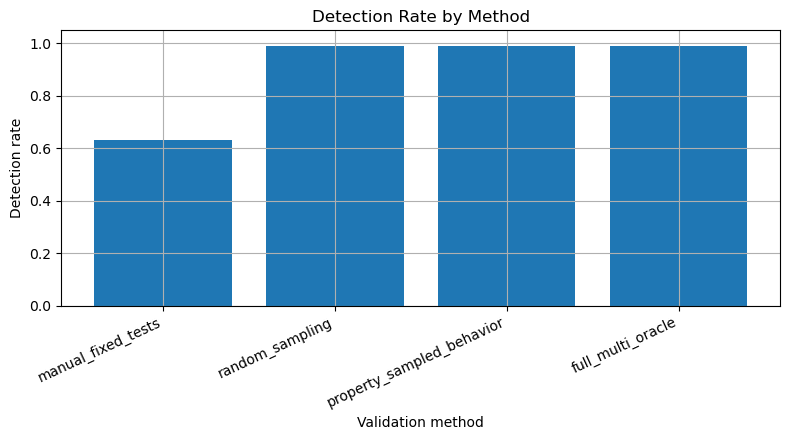

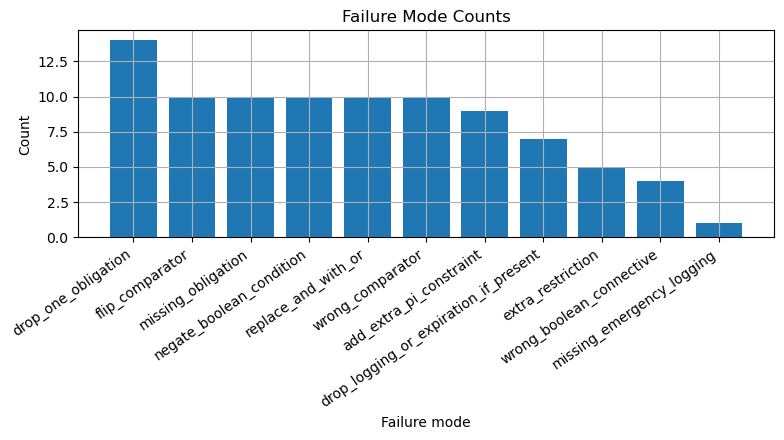

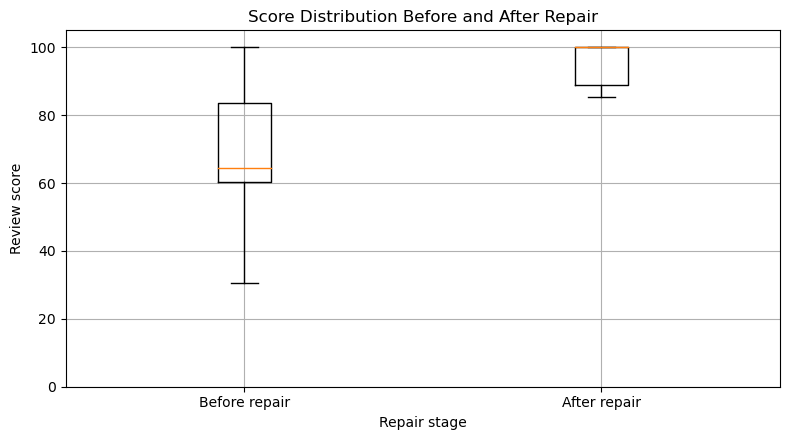

In [15]:
plt.figure()
plt.bar(method_summary_df["method"], method_summary_df["detection_rate"])
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.title("Detection Rate by Method")
plt.ylabel("Detection rate")
plt.xlabel("Validation method")
plt.tight_layout()
plt.show()
failure_mode_counts = pd.concat([pd.DataFrame({"failure_mode": [c["intended_fault"] for c in candidates]}), pd.DataFrame({"failure_mode": [m["mutation_type"] for m in mutants]})]).groupby("failure_mode").size().sort_values(ascending=False)
plt.figure()
plt.bar(failure_mode_counts.index, failure_mode_counts.values)
plt.xticks(rotation=35, ha="right")
plt.title("Failure Mode Counts")
plt.ylabel("Count")
plt.xlabel("Failure mode")
plt.tight_layout()
plt.show()
plt.figure()
plt.boxplot([repair_df["score_before"], repair_df["score_after"]], labels=["Before repair", "After repair"])
plt.ylim(0, 105)
plt.title("Score Distribution Before and After Repair")
plt.ylabel("Review score")
plt.xlabel("Repair stage")
plt.tight_layout()
plt.show()


This stage extracts three concise case studies for use in a written report. The cases are selected automatically to illustrate an under-constrained specification, an over-constrained specification, and a metamorphic-relation violation.


In [ ]:
def output_for_case(item_id, env):
    item = item_lookup[item_id]
    requirement = requirements_by_id[item["requirement_id"]]
    return eval_expr(requirement["gold_spec"], env), eval_expr(item["spec"], env)

def make_case(row, issue_type):
    item = item_lookup[row["item_id"]]
    requirement = requirements_by_id[item["requirement_id"]]
    if issue_type == "metamorphic violation" and row["first_violation"] is not None:
        counterexample = row["first_violation"]
        env = counterexample["base_input"]
    else:
        counterexample = row["first_counterexample"] if row["first_counterexample"] is not None else row["smt_counterexample"]
        env = counterexample
    gold_output, candidate_output = output_for_case(row["item_id"], env)
    interpretations = {"under-constrained": "The candidate allows an input that the gold specification denies. This is the most safety-critical pattern because the generated policy has lost at least one guard that blocks unsafe access.", "over-constrained": "The candidate denies an input that the gold specification allows. This is less directly unsafe, but it indicates that the generated specification does not faithfully implement the stated access policy.", "metamorphic violation": "The candidate violates a metamorphic safety relation. Even when sampled behavioral agreement is high, this relation exposes an inconsistent response to a controlled safety-relevant input change."}
    return {"requirement": requirement["natural_language"], "candidate_name": item.get("name"), "suspected_issue": issue_type, "counterexample": counterexample, "gold_output": bool(gold_output), "candidate_output": bool(candidate_output), "missing_obligations": row["missing_obligation_names"], "interpretation": interpretations[issue_type]}

under_row = review_df[(review_df["kind"] == "candidate") & (review_df["under_constrained_count"] > 0)].sort_values("under_constrained_count", ascending=False).iloc[0]
over_candidates = review_df[(review_df["kind"] == "candidate") & (review_df["over_constrained_count"] > 0) & (review_df["under_constrained_count"] == 0)]
over_row = over_candidates.sort_values("over_constrained_count", ascending=False).iloc[0] if len(over_candidates) else review_df[(review_df["kind"] == "candidate") & (review_df["over_constrained_count"] > 0)].sort_values("over_constrained_count", ascending=False).iloc[0]
metamorphic_row = review_df[(review_df["kind"] == "candidate") & (review_df["violation_count"] > 0)].sort_values("violation_count", ascending=False).iloc[0]
case_studies = [make_case(under_row, "under-constrained"), make_case(over_row, "over-constrained"), make_case(metamorphic_row, "metamorphic violation")]
for index, case in enumerate(case_studies, start=1):
    print(f"Case study {index}")
    print(json.dumps(case, indent=2))


Case study 1
{
  "requirement": "External collaborators may access only anonymized, non-sensitive, low-to-moderate-risk records through logged access.",
  "candidate_name": "over-permissive Boolean connective",
  "suspected_issue": "under-constrained",
  "counterexample": {
    "user": {
      "role": "researcher",
      "clearance": 4,
      "training_completed": true,
      "approval_active": true,
      "approval_expired": false,
      "supervised_by_pi": false
    },
    "record": {
      "risk_level": 4,
      "anonymized": false,
      "sensitive": true
    },
    "context": {
      "emergency": false,
      "logged": true
    }
  },
  "gold_output": false,
  "candidate_output": true,
  "missing_obligations": [],
  "interpretation": "The candidate allows an input that the gold specification denies. This is the most safety-critical pattern because the generated policy has lost at least one guard that blocks unsafe access."
}
Case study 2
{
  "requirement": "Access to controlled bi

This stage exports the experiment artifacts needed for a short research report and prints a concise conclusion with the key quantitative results.


In [17]:
review_df.to_csv("review_cards.csv", index=False)
repair_df.to_csv("repair_results.csv", index=False)
method_summary_df.to_csv("method_summary.csv", index=False)
with open("case_studies.json", "w", encoding="utf-8") as f:
    json.dump(case_studies, f, indent=2)
full_multi_row = method_summary_df[method_summary_df["method"] == "full_multi_oracle"].iloc[0]
conclusion = {"requirements": len(requirements), "candidates": len(candidates), "mutants": len(mutants), "full_multi_oracle_detection_rate": round(float(full_multi_row["detection_rate"]), 3), "high_severity_detection_rate": round(float(full_multi_row["high_severity_detection_rate"]), 3), "repair_success_rate": round(float(repair_success_rate), 3)}
print("Concise conclusion")
print(json.dumps(conclusion, indent=2))


Concise conclusion
{
  "requirements": 10,
  "candidates": 30,
  "mutants": 60,
  "full_multi_oracle_detection_rate": 0.989,
  "high_severity_detection_rate": 1.0,
  "repair_success_rate": 0.967
}


This stage connects to the Gemini API and uses a real LLM to generate restricted DSL specifications directly from natural-language requirements. To keep outputs parseable, the model is asked to return only JSON using the existing DSL operators: AND, OR, NOT, EQ, NEQ, GE, GT, LE, LT, FIELD, and CONST. The implementation first tries Gemini structured output with a response schema, then falls back to ordinary JSON prompting and json.loads parsing if structured output is unavailable or fails.


In [18]:
%pip install google-genai pydantic
%pip install --upgrade typing_extensions


Looking in indexes: http://mirrors.aliyun.com/pypi/simple/
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: http://mirrors.aliyun.com/pypi/simple/
Note: you may need to restart the kernel to use updated packages.


In [19]:
import os
import json
import time
import hashlib
from typing import List, Dict, Any, Optional
from pydantic import BaseModel, Field, ValidationError
from google import genai
try:
    from google.genai import types
except Exception:
    types = None

class GeneratedSpec(BaseModel):
    spec_name: str
    spec: Dict[str, Any]
    explanation: str
    confidence: float

class GeneratedSpecBatch(BaseModel):
    requirement_id: str
    candidates: List[GeneratedSpec]

allowed_generated_ops = {"AND", "OR", "NOT", "EQ", "NEQ", "GE", "GT", "LE", "LT", "FIELD", "CONST"}
allowed_generated_fields = {
    "user.role",
    "user.clearance",
    "user.training_completed",
    "user.approval_active",
    "user.approval_expired",
    "user.supervised_by_pi",
    "record.risk_level",
    "record.anonymized",
    "record.sensitive",
    "context.emergency",
    "context.logged",
}
prompt_modes = ["direct_translation", "obligation_guided", "adversarial_review"]

def field_path_to_string(path):
    return ".".join(path) if isinstance(path, list) else path

def normalize_const_value(value):
    if isinstance(value, str):
        lower = value.strip().lower()
        if lower == "true":
            return True
        if lower == "false":
            return False
    return value

def normalize_generated_expr(expr):
    if isinstance(expr, str):
        if expr in allowed_generated_fields:
            return {"op": "FIELD", "path": expr.split(".")}
        return {"op": "CONST", "value": normalize_const_value(expr)}
    if isinstance(expr, bool) or isinstance(expr, int):
        return {"op": "CONST", "value": expr}
    if not isinstance(expr, dict):
        return expr
    node = copy.deepcopy(expr)
    if "operator" in node and "op" not in node:
        node["op"] = node.pop("operator")
    if "children" in node and "args" not in node:
        node["args"] = node.pop("children")
    op = node.get("op")
    if isinstance(op, str):
        node["op"] = op.upper()
    op = node.get("op")
    if "field" in node and op is None:
        return {"op": "FIELD", "path": str(node["field"]).split(".")}
    if op == "FIELD":
        path = node.get("path", node.get("field"))
        return {"op": "FIELD", "path": str(field_path_to_string(path)).split(".")}
    if op == "CONST":
        return {"op": "CONST", "value": normalize_const_value(node.get("value"))}
    if op in ["AND", "OR"]:
        args = node.get("args", [])
        return {"op": op, "args": [normalize_generated_expr(arg) for arg in args]}
    if op == "NOT":
        return {"op": "NOT", "arg": normalize_generated_expr(node.get("arg"))}
    if op in ["EQ", "NEQ", "GE", "GT", "LE", "LT"]:
        left = normalize_generated_expr(node.get("left", node.get("args", [None, None])[0] if isinstance(node.get("args"), list) and len(node.get("args")) > 0 else None))
        right_raw = node.get("right", node.get("args", [None, None])[1] if isinstance(node.get("args"), list) and len(node.get("args")) > 1 else node.get("value"))
        right = normalize_generated_expr(right_raw)
        return {"op": op, "args": [left, right]}
    if "value" in node and len(node) == 1:
        return {"op": "CONST", "value": normalize_const_value(node["value"])}
    return node

def validate_generated_expr(expr):
    if not isinstance(expr, dict):
        return False, "node is not a dict"
    op = expr.get("op")
    if op not in allowed_generated_ops:
        return False, f"unsupported op {op}"
    if op == "FIELD":
        path = field_path_to_string(expr.get("path"))
        if path not in allowed_generated_fields:
            return False, f"invalid FIELD path {path}"
        return True, ""
    if op == "CONST":
        value = expr.get("value")
        if isinstance(value, (bool, int, str)):
            return True, ""
        return False, f"invalid CONST value type {type(value).__name__}"
    if op in ["AND", "OR"]:
        args = expr.get("args")
        if not isinstance(args, list) or not args:
            return False, f"{op} requires non-empty args list"
        for arg in args:
            ok, error = validate_generated_expr(arg)
            if not ok:
                return False, error
        return True, ""
    if op == "NOT":
        if "arg" not in expr:
            return False, "NOT requires arg"
        return validate_generated_expr(expr["arg"])
    if op in ["EQ", "NEQ", "GE", "GT", "LE", "LT"]:
        if "left" in expr and "right" in expr:
            children = [expr["left"], expr["right"]]
        elif isinstance(expr.get("args"), list) and len(expr["args"]) == 2:
            children = expr["args"]
        else:
            return False, f"{op} requires left and right"
        for child in children:
            ok, error = validate_generated_expr(child)
            if not ok:
                return False, error
        return True, ""
    return False, "unreachable validation state"

def generated_expr_to_prompt_format(expr):
    normalized = normalize_generated_expr(expr)
    op = normalized.get("op")
    if op in ["EQ", "NEQ", "GE", "GT", "LE", "LT"]:
        return {"op": op, "left": generated_expr_to_prompt_format(normalized["args"][0]), "right": generated_expr_to_prompt_format(normalized["args"][1])}
    if op in ["AND", "OR"]:
        return {"op": op, "args": [generated_expr_to_prompt_format(arg) for arg in normalized["args"]]}
    if op == "NOT":
        return {"op": "NOT", "arg": generated_expr_to_prompt_format(normalized["arg"])}
    if op == "FIELD":
        return {"op": "FIELD", "path": field_path_to_string(normalized["path"])}
    if op == "CONST":
        return {"op": "CONST", "value": normalized["value"]}
    return normalized

def build_llm_prompt(requirement, mode):
    obligation_lines = "\n".join([f"- {o['id']}: {o['name']} severity={o['severity']} predicate={expr_to_string(o['predicate'])}" for o in requirement["obligations"]])
    mode_instruction = {
        "direct_translation": "Translate the natural-language requirement directly into one restricted DSL specification.",
        "obligation_guided": "Use the listed obligations as traceability anchors and generate a DSL specification that covers all obligations.",
        "adversarial_review": "Act as a strict safety reviewer and generate a conservative specification, but do not add unrelated restrictions such as PI-only access unless the requirement says so.",
    }[mode]
    return f"""Generate exactly one candidate safety specification for this biosecurity access-control requirement.

Requirement id: {requirement['id']}
Natural language requirement: {requirement['natural_language']}

Available fields:
user.role in [\"PI\", \"researcher\", \"trainee\", \"external\"]
user.clearance is integer 0 to 5
user.training_completed is boolean
user.approval_active is boolean
user.approval_expired is boolean
user.supervised_by_pi is boolean
record.risk_level is integer 0 to 5
record.anonymized is boolean
record.sensitive is boolean
context.emergency is boolean
context.logged is boolean

DSL operators:
AND and OR use args, a non-empty list of child expressions.
NOT uses arg.
EQ, NEQ, GE, GT, LE, and LT use left and right.
FIELD uses path.
CONST uses value.

Output must be valid JSON matching this schema:
{{"requirement_id": "{requirement['id']}", "candidates": [{{"spec_name": "short name", "spec": {{"op": "AND", "args": []}}, "explanation": "brief rationale", "confidence": 0.0}}]}}

DSL format example:
{{"op": "AND", "args": [
  {{"op": "GE", "left": {{"op": "FIELD", "path": "user.clearance"}}, "right": {{"op": "FIELD", "path": "record.risk_level"}}}},
  {{"op": "EQ", "left": {{"op": "FIELD", "path": "user.training_completed"}}, "right": {{"op": "CONST", "value": true}}}}
]}}

Rules:
Only output JSON.
Do not output Python code.
Do not introduce fields outside the available field list.
Use only these operators: AND, OR, NOT, EQ, NEQ, GE, GT, LE, LT, FIELD, CONST.
For ambiguity, choose a safer deny-by-default interpretation, but do not add obviously unrelated PI-only restrictions.
Return exactly one candidate in the candidates list.

Obligations for traceability:
{obligation_lines}

Mode instruction:
{mode_instruction}
"""

def extract_response_text(response):
    if hasattr(response, "text") and response.text:
        return response.text
    try:
        return response.candidates[0].content.parts[0].text
    except Exception:
        return str(response)

def parse_json_text(text):
    cleaned = text.strip()
    if cleaned.startswith("```"):
        cleaned = cleaned.strip("`")
        cleaned = cleaned.replace("json\n", "", 1).replace("JSON\n", "", 1)
    return json.loads(cleaned)

def call_gemini_for_spec(requirement, mode, model_name="gemini-2.5-flash", temperature=0.7, max_retries=3):
    api_key = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
    if not api_key:
        return {"requirement_id": requirement["id"], "mode": mode, "spec_name": None, "spec": None, "explanation": "", "confidence": None, "raw_response": "", "parse_success": False, "parse_error": "Missing GEMINI_API_KEY or GOOGLE_API_KEY. Create a Gemini API key in Google AI Studio, then set os.environ[\"GEMINI_API_KEY\"] = \"...\" in this notebook or configure it as a system environment variable."}
    client = genai.Client(api_key=api_key)
    prompt = build_llm_prompt(requirement, mode)
    last_error = ""
    for attempt in range(max_retries):
        time.sleep(1)
        try:
            raw_response = ""
            try:
                if types is not None:
                    response = client.models.generate_content(model=model_name, contents=prompt, config=types.GenerateContentConfig(temperature=temperature, response_mime_type="application/json", response_schema=GeneratedSpecBatch))
                else:
                    response = client.models.generate_content(model=model_name, contents=prompt, config={"temperature": temperature, "response_mime_type": "application/json", "response_schema": GeneratedSpecBatch.model_json_schema()})
                raw_response = extract_response_text(response)
                data = parse_json_text(raw_response)
            except Exception as structured_error:
                fallback_prompt = prompt + "\nReturn only the JSON object. No markdown fences."
                response = client.models.generate_content(model=model_name, contents=fallback_prompt, config={"temperature": temperature})
                raw_response = extract_response_text(response)
                data = parse_json_text(raw_response)
            batch = GeneratedSpecBatch.model_validate(data)
            if not batch.candidates:
                raise ValueError("no candidates returned")
            candidate = batch.candidates[0]
            normalized_spec = normalize_generated_expr(candidate.spec)
            ok, error = validate_generated_expr(normalized_spec)
            if not ok:
                raise ValueError(error)
            return {"requirement_id": requirement["id"], "mode": mode, "spec_name": candidate.spec_name, "spec": normalized_spec, "explanation": candidate.explanation, "confidence": float(candidate.confidence), "raw_response": raw_response, "parse_success": True, "parse_error": ""}
        except Exception as error:
            last_error = str(error)
    return {"requirement_id": requirement["id"], "mode": mode, "spec_name": None, "spec": None, "explanation": "", "confidence": None, "raw_response": "", "parse_success": False, "parse_error": last_error}

def generate_real_llm_candidates(requirements, max_requirements=10, modes=None):
    modes = modes or prompt_modes
    cache_path = "real_llm_specs_raw.json"
    api_key = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
    records = None
    if os.path.exists(cache_path):
        with open(cache_path, "r", encoding="utf-8") as f:
            records = json.load(f)
        if records:
            print("Loaded cached real LLM specs from real_llm_specs_raw.json")
            print("Delete real_llm_specs_raw.json to force fresh Gemini calls.")
        elif not api_key:
            print("Loaded empty real_llm_specs_raw.json and no API key is available.")
        else:
            print("Cached real LLM file is empty and an API key is available, so Gemini generation will run again.")
            records = None
    if records is None and not api_key:
        print("Gemini API key not detected. Create a key in Google AI Studio and set os.environ[\"GEMINI_API_KEY\"] = \"...\" in this notebook, or set GEMINI_API_KEY or GOOGLE_API_KEY as a system environment variable. The real LLM experiment is skipped until a key is available.")
        records = []
    if records is None:
        records = []
        for requirement in requirements[:max_requirements]:
            for mode in modes:
                records.append(call_gemini_for_spec(requirement, mode))
        with open(cache_path, "w", encoding="utf-8") as f:
            json.dump(records, f, indent=2)
    total = len(records)
    successes = sum(1 for record in records if record.get("parse_success"))
    failures = total - successes
    print("Total Gemini records:", total)
    print("Successful parses:", successes)
    print("Failures:", failures)
    return records

real_llm_raw_records = generate_real_llm_candidates(requirements, max_requirements=10)
real_llm_specs = []
real_llm_parse_failures = []
for record in real_llm_raw_records:
    if record.get("parse_success"):
        normalized_spec = normalize_generated_expr(record["spec"])
        ok, error = validate_generated_expr(normalized_spec)
        if ok:
            real_llm_specs.append({"id": f"{record['requirement_id']}-LLM-{record['mode']}", "requirement_id": record["requirement_id"], "name": f"gemini_{record['mode']}", "spec": normalized_spec, "source": "gemini_api", "prompt_mode": record["mode"], "confidence": record.get("confidence"), "explanation": record.get("explanation", "")})
        else:
            failed = record.copy()
            failed["validation_error"] = error
            real_llm_parse_failures.append(failed)
    else:
        real_llm_parse_failures.append(record)
with open("real_llm_parse_failures.json", "w", encoding="utf-8") as f:
    json.dump(real_llm_parse_failures, f, indent=2)
parse_success_rate = len(real_llm_specs) / len(real_llm_raw_records) if real_llm_raw_records else 0.0
print("Real LLM parse success rate:", round(parse_success_rate, 3))
if real_llm_raw_records and parse_success_rate < 0.8:
    print("Warning: parse success rate is below 80%. Consider checking the schema, simplifying the prompt, or switching Gemini models.")
display(pd.DataFrame([{k: v for k, v in item.items() if k != "spec"} for item in real_llm_specs]).head(10))


Loaded cached real LLM specs from real_llm_specs_raw.json
Delete real_llm_specs_raw.json to force fresh Gemini calls.
Total Gemini records: 30
Successful parses: 20
Failures: 10
Real LLM parse success rate: 0.667


,id,requirement_id,name,source,prompt_mode,confidence,explanation
0,R01-LLM-direct_translation,R01,gemini_direct_translation,gemini_api,direct_translation,1.0,"Requires that the user's clearance level is greater than or equal to the record's risk level, the user has completed..."
1,R01-LLM-obligation_guided,R01,gemini_obligation_guided,gemini_api,obligation_guided,1.0,"Mandates that the user's clearance level is greater than or equal to the record's risk level (R01-O1), their trainin..."
2,R01-LLM-adversarial_review,R01,gemini_adversarial_review,gemini_api,adversarial_review,1.0,"Ensures that access is only granted if the user's clearance is greater than or equal to the record's risk level, tra..."
3,R02-LLM-direct_translation,R02,gemini_direct_translation,gemini_api,direct_translation,1.0,"Ensures that external collaborators are excluded, and that training has been completed and approval is currently act..."
4,R02-LLM-obligation_guided,R02,gemini_obligation_guided,gemini_api,obligation_guided,1.0,"Enforces that the user is not an external collaborator, has completed the required training, and has an active appro..."
5,R02-LLM-adversarial_review,R02,gemini_adversarial_review,gemini_api,adversarial_review,1.0,"Enforces that the user is not an external collaborator, has completed the required training, and has an active appro..."
6,R03-LLM-direct_translation,R03,gemini_direct_translation,gemini_api,direct_translation,1.0,"Enforces that the user's approval is active, not expired, that the access is logged (auditable), and that the user h..."
7,R03-LLM-obligation_guided,R03,gemini_obligation_guided,gemini_api,obligation_guided,1.0,"Ensures that access is only granted if the user's approval is active (R03-O1), the approval is not expired (R03-O2),..."
8,R03-LLM-adversarial_review,R03,gemini_adversarial_review,gemini_api,adversarial_review,1.0,"Enforces that access is only allowed when approval is active, approval is not expired, the session is logged (audita..."
9,R04-LLM-direct_translation,R04,gemini_direct_translation,gemini_api,direct_translation,1.0,"Ensures that access is only granted if the user's approval is active and not expired, their clearance level is great..."


This stage runs the exact same validator used earlier on the real LLM-generated specifications. This separates controlled evaluation from live-model evaluation: controlled mutants demonstrate that the validator can detect known injected errors, simulated candidates represent typical LLM-style mistakes, and real LLM candidates show the actual quality and failure modes of Gemini-generated specifications.


In [20]:
def run_real_llm_oracles(real_items):
    coverage_rows_local, behavior_rows_local, metamorphic_rows_local, smt_rows_local = [], [], [], []
    for item in real_items:
        requirement = requirements_by_id[item["requirement_id"]]
        coverage_row = {"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": "real_llm_candidate", "name": item["name"], "fault_type": item["prompt_mode"]}
        coverage_row.update(compute_obligation_coverage(requirement, item["spec"]))
        coverage_rows_local.append(coverage_row)
        behavior_row = {"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": "real_llm_candidate", "fault_type": item["prompt_mode"]}
        behavior_row.update(evaluate_behavior(requirement, item, sampled_inputs[item["requirement_id"]]))
        behavior_rows_local.append(behavior_row)
        metamorphic_row = {"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": "real_llm_candidate", "fault_type": item["prompt_mode"]}
        metamorphic_row.update(evaluate_metamorphic(item, sampled_inputs[item["requirement_id"]][:1000]))
        metamorphic_rows_local.append(metamorphic_row)
        counterexample, elapsed = find_smt_counterexample(requirement["gold_spec"], item["spec"])
        smt_rows_local.append({"item_id": item["id"], "requirement_id": item["requirement_id"], "kind": "real_llm_candidate", "fault_type": item["prompt_mode"], "has_smt_counterexample": counterexample is not None, "smt_counterexample": counterexample, "smt_time": elapsed})
    return pd.DataFrame(coverage_rows_local), pd.DataFrame(behavior_rows_local), pd.DataFrame(metamorphic_rows_local), pd.DataFrame(smt_rows_local)

if real_llm_specs:
    real_llm_coverage_df, real_llm_behavior_df, real_llm_metamorphic_df, real_llm_smt_df = run_real_llm_oracles(real_llm_specs)
    real_llm_review_full_df = build_review_dataframe(real_llm_coverage_df, real_llm_behavior_df, real_llm_metamorphic_df, real_llm_smt_df)
    metadata_df = pd.DataFrame([{k: v for k, v in item.items() if k != "spec"} for item in real_llm_specs])
    real_llm_review_df = real_llm_review_full_df.merge(metadata_df, left_on="item_id", right_on="id", how="left", suffixes=("", "_meta"))
    real_llm_review_df["metamorphic_violation_rate"] = real_llm_review_df["violation_rate"]
    real_llm_review_df = real_llm_review_df[["id", "requirement_id", "name_meta", "prompt_mode", "confidence", "coverage_rate", "missing_high_severity_count", "agreement_rate", "under_constrained_count", "over_constrained_count", "metamorphic_violation_rate", "has_smt_counterexample", "score", "risk_level", "missing_obligation_names", "first_counterexample", "smt_counterexample", "explanation"]].rename(columns={"name_meta": "name"})
else:
    real_llm_coverage_df = pd.DataFrame()
    real_llm_behavior_df = pd.DataFrame()
    real_llm_metamorphic_df = pd.DataFrame()
    real_llm_smt_df = pd.DataFrame()
    real_llm_review_df = pd.DataFrame(columns=["id", "requirement_id", "name", "prompt_mode", "confidence", "coverage_rate", "missing_high_severity_count", "agreement_rate", "under_constrained_count", "over_constrained_count", "metamorphic_violation_rate", "has_smt_counterexample", "score", "risk_level"])
    print("Real LLM validation skipped because no successfully parsed Gemini specifications are available.")
display(real_llm_review_df.head(15))


,id,requirement_id,name,prompt_mode,confidence,coverage_rate,missing_high_severity_count,agreement_rate,under_constrained_count,over_constrained_count,metamorphic_violation_rate,has_smt_counterexample,score,risk_level,missing_obligation_names,first_counterexample,smt_counterexample,explanation
0,R05-LLM-direct_translation,R05,gemini_direct_translation,direct_translation,0.95,0.8,0,0.2625,1475,0,0.0,True,46.5625,high,[external role],"{'user': {'role': 'researcher', 'clearance': 4, 'training_completed': True, 'approval_active': True, 'approval_expir...","{'user': {'role': 'PI', 'clearance': 0, 'training_completed': False, 'approval_active': False, 'approval_expired': F...","If the user is an external collaborator, they are restricted to accessing records that are anonymized, non-sensitive..."
1,R05-LLM-adversarial_review,R05,gemini_adversarial_review,adversarial_review,1.00,0.8,0,0.2625,1475,0,0.0,True,46.5625,high,[external role],"{'user': {'role': 'researcher', 'clearance': 4, 'training_completed': True, 'approval_active': True, 'approval_expir...","{'user': {'role': 'PI', 'clearance': 0, 'training_completed': False, 'approval_active': False, 'approval_expired': F...","Ensures that if the user is an external collaborator, they are restricted to accessing records that are anonymized, ..."
2,R07-LLM-direct_translation,R07,gemini_direct_translation,direct_translation,1.00,0.8,0,0.3425,1315,0,0.0,True,48.5625,high,[high risk record],"{'user': {'role': 'PI', 'clearance': 2, 'training_completed': True, 'approval_active': False, 'approval_expired': Fa...","{'user': {'role': 'researcher', 'clearance': 0, 'training_completed': True, 'approval_active': False, 'approval_expi...","If a biological record is high-risk (risk_level >= 4), access is restricted to PIs who have sufficient clearance, co..."
3,R05-LLM-obligation_guided,R05,gemini_obligation_guided,obligation_guided,1.00,1.0,0,0.2625,1475,0,0.0,True,51.5625,high,[],"{'user': {'role': 'researcher', 'clearance': 4, 'training_completed': True, 'approval_active': True, 'approval_expir...","{'user': {'role': 'PI', 'clearance': 0, 'training_completed': False, 'approval_active': False, 'approval_expired': F...","Ensures that if the accessing user is an external collaborator, the accessed record must be anonymized, non-sensitiv..."
4,R07-LLM-obligation_guided,R07,gemini_obligation_guided,obligation_guided,1.00,1.0,0,0.3425,1315,0,0.0,True,53.5625,high,[],"{'user': {'role': 'PI', 'clearance': 2, 'training_completed': True, 'approval_active': False, 'approval_expired': Fa...","{'user': {'role': 'researcher', 'clearance': 0, 'training_completed': True, 'approval_active': False, 'approval_expi...","Enforces that if a record is high-risk (risk_level >= 4), access is granted only if the user is a PI, has sufficient..."
5,R01-LLM-direct_translation,R01,gemini_direct_translation,direct_translation,1.00,1.0,0,1.0000,0,0,0.0,False,100.0000,low,[],None,None,"Requires that the user's clearance level is greater than or equal to the record's risk level, the user has completed..."
6,R01-LLM-obligation_guided,R01,gemini_obligation_guided,obligation_guided,1.00,1.0,0,1.0000,0,0,0.0,False,100.0000,low,[],None,None,"Mandates that the user's clearance level is greater than or equal to the record's risk level (R01-O1), their trainin..."
7,R01-LLM-adversarial_review,R01,gemini_adversarial_review,adversarial_review,1.00,1.0,0,1.0000,0,0,0.0,False,100.0000,low,[],None,None,"Ensures that access is only granted if the user's clearance is greater than or equal to the record's risk level, tra..."
8,R02-LLM-direct_translation,R02,gemini_direct_translation,direct_translation,1.00,1.0,0,1.0000,0,0,0.0,False,100.0000,low,[],None,None,"Ensures that external collaborators are excluded, and that training has been completed and approval is currently act..."
9,R02-LLM-obligation_guided,R02,gemini_obligation_guided,obligation_guided,1.00,1.0,0,1.0000,0,0,0.0,False,100.0000,low,[],None,None,"Enforces that the user is not an ext

This stage compares simulated candidates, controlled mutants, and real LLM candidates. The comparison is useful for reporting because each source has a different role: mutants provide controlled faults, simulated candidates approximate typical LLM errors, and real LLM candidates measure live generation quality.


In [ ]:
if len(real_llm_review_df):
    
    real_llm_summary_df = pd.DataFrame([{"num_requirements": real_llm_review_df["requirement_id"].nunique(), "num_real_llm_specs": len(real_llm_review_df), "parse_success_rate": parse_success_rate, "mean_score": real_llm_review_df["score"].mean(), "median_score": real_llm_review_df["score"].median(), "high_risk_count": int((real_llm_review_df["risk_level"] == "high").sum()), "medium_risk_count": int((real_llm_review_df["risk_level"] == "medium").sum()), "low_risk_count": int((real_llm_review_df["risk_level"] == "low").sum()), "mean_coverage_rate": real_llm_review_df["coverage_rate"].mean(), "mean_agreement_rate": real_llm_review_df["agreement_rate"].mean(), "total_under_constrained_count": int(real_llm_review_df["under_constrained_count"].sum()), "total_over_constrained_count": int(real_llm_review_df["over_constrained_count"].sum()), "smt_counterexample_rate": real_llm_review_df["has_smt_counterexample"].mean(), "metamorphic_violation_rate": (real_llm_review_df["metamorphic_violation_rate"] > 0).mean()}])
    prompt_mode_summary_df = real_llm_review_df.groupby("prompt_mode").agg(count=("id", "size"), mean_score=("score", "mean"), mean_coverage_rate=("coverage_rate", "mean"), mean_agreement_rate=("agreement_rate", "mean"), mean_under_constrained_count=("under_constrained_count", "mean"), mean_over_constrained_count=("over_constrained_count", "mean"), high_risk_rate=("risk_level", lambda s: (s == "high").mean()), smt_counterexample_rate=("has_smt_counterexample", "mean"), mean_confidence=("confidence", "mean")).reset_index()
    
else:
    real_llm_summary_df = pd.DataFrame([{"num_requirements": 0, "num_real_llm_specs": 0, "parse_success_rate": parse_success_rate, "mean_score": np.nan, "median_score": np.nan, "high_risk_count": 0, "medium_risk_count": 0, "low_risk_count": 0, "mean_coverage_rate": np.nan, "mean_agreement_rate": np.nan, "total_under_constrained_count": 0, "total_over_constrained_count": 0, "smt_counterexample_rate": np.nan, "metamorphic_violation_rate": np.nan}])
    prompt_mode_summary_df = pd.DataFrame(columns=["prompt_mode", "count", "mean_score", "mean_coverage_rate", "mean_agreement_rate", "mean_under_constrained_count", "mean_over_constrained_count", "high_risk_rate", "smt_counterexample_rate", "mean_confidence"])
    
controlled_candidate_source = review_df[review_df["kind"] == "candidate"].copy()

controlled_candidate_source["spec_source"] = "controlled_candidate"

controlled_mutant_source = review_df[review_df["kind"] == "mutant"].copy()

controlled_mutant_source["spec_source"] = "controlled_mutant"

real_source = real_llm_review_df.rename(columns={"id": "item_id", "metamorphic_violation_rate": "violation_rate"}).copy()

real_source["spec_source"] = "real_llm_candidate"

source_frames = [controlled_candidate_source, controlled_mutant_source]

if len(real_source):
    source_frames.append(real_source)
    
source_comparison_input = pd.concat(source_frames, ignore_index=True, sort=False)
spec_source_comparison_df = source_comparison_input.groupby("spec_source").agg(count=("item_id", "size"), mean_score=("score", "mean"), high_risk_rate=("risk_level", lambda s: (s == "high").mean()), mean_agreement_rate=("agreement_rate", "mean"), mean_coverage_rate=("coverage_rate", "mean"), smt_counterexample_rate=("has_smt_counterexample", "mean")).reset_index()

print("Real LLM summary")
display(real_llm_summary_df)
print("Prompt mode summary")
display(prompt_mode_summary_df)
print("Spec source comparison")
display(spec_source_comparison_df)


Real LLM summary


,num_requirements,num_real_llm_specs,parse_success_rate,mean_score,median_score,high_risk_count,medium_risk_count,low_risk_count,mean_coverage_rate,mean_agreement_rate,total_under_constrained_count,total_over_constrained_count,smt_counterexample_rate,metamorphic_violation_rate
0,7,20,0.666667,87.340625,100.0,5,0,15,0.97,0.823625,7055,0,0.25,0.0


Prompt mode summary


,prompt_mode,count,mean_score,mean_coverage_rate,mean_agreement_rate,mean_under_constrained_count,mean_over_constrained_count,high_risk_rate,smt_counterexample_rate,mean_confidence
0,adversarial_review,6,91.093750,0.966667,0.877083,245.833333,0.0,0.166667,0.166667,1.000000
1,direct_translation,7,85.017857,0.942857,0.800714,398.571429,0.0,0.285714,0.285714,0.992857
2,obligation_guided,7,86.446429,1.000000,0.800714,398.571429,0.0,0.285714,0.285714,1.000000


Spec source comparison


,spec_source,count,mean_score,high_risk_rate,mean_agreement_rate,mean_coverage_rate,smt_counterexample_rate
0,controlled_candidate,30,70.049220,0.600000,0.826550,0.788889,0.966667
1,controlled_mutant,60,70.247723,0.483333,0.783758,0.799722,1.000000
2,real_llm_candidate,20,87.340625,0.250000,0.823625,0.970000,0.250000


This stage outputs case studies from the real LLM-generated specifications. The selected examples illustrate a high-risk direct translation, a stronger obligation-guided case, and an over-constrained adversarial-review case when available.


In [ ]:
def get_real_llm_item(item_id):
    return next(item for item in real_llm_specs if item["id"] == item_id)

def real_case_from_row(row, label):
    item = get_real_llm_item(row["id"])
    requirement = requirements_by_id[item["requirement_id"]]
    counterexample = row["first_counterexample"] if row.get("first_counterexample") is not None else row.get("smt_counterexample")
    env = counterexample if isinstance(counterexample, dict) and "user" in counterexample else row.get("smt_counterexample")
    if isinstance(env, dict) and "base_input" in env:
        env = env["base_input"]
    if isinstance(env, dict) and "user" in env:
        gold_output = eval_expr(requirement["gold_spec"], env)
        candidate_output = eval_expr(item["spec"], env)
    else:
        gold_output, candidate_output = None, None
    if label == "direct_translation_high_risk":
        interpretation = "This case shows how direct translation can miss safety-relevant obligations or produce behavior that is too permissive relative to the reference policy."
    elif label == "obligation_guided_lower_risk":
        interpretation = "This case shows whether obligation-guided prompting improves traceability and validator scores by making the model attend to explicit safety obligations."
    else:
        interpretation = "This case shows the tradeoff of adversarial-review prompting: conservative reasoning can reduce unsafe allowance but may deny accesses that the requirement permits."
    return {"requirement": requirement["natural_language"], "prompt_mode": item["prompt_mode"], "model_explanation": item["explanation"], "generated_dsl_spec": expr_to_string(item["spec"]), "missing_obligations": row.get("missing_obligation_names", []), "counterexample": counterexample, "gold_output": None if gold_output is None else bool(gold_output), "candidate_output": None if candidate_output is None else bool(candidate_output), "smt_counterexample": row.get("smt_counterexample"), "interpretation": interpretation}

if len(real_llm_review_df):
    direct_pool = real_llm_review_df[(real_llm_review_df["prompt_mode"] == "direct_translation") & (real_llm_review_df["risk_level"] == "high")]
    direct_row = direct_pool.sort_values("score").iloc[0] if len(direct_pool) else real_llm_review_df[real_llm_review_df["prompt_mode"] == "direct_translation"].sort_values("score").iloc[0]
    obligation_pool = real_llm_review_df[real_llm_review_df["prompt_mode"] == "obligation_guided"]
    obligation_row = obligation_pool.sort_values(["risk_level", "score"], ascending=[True, False]).iloc[0] if len(obligation_pool) else real_llm_review_df.sort_values("score", ascending=False).iloc[0]
    adversarial_pool = real_llm_review_df[(real_llm_review_df["prompt_mode"] == "adversarial_review") & (real_llm_review_df["over_constrained_count"] > 0)]
    over_pool = real_llm_review_df[real_llm_review_df["over_constrained_count"] > 0]
    adversarial_row = adversarial_pool.sort_values("over_constrained_count", ascending=False).iloc[0] if len(adversarial_pool) else over_pool.sort_values("over_constrained_count", ascending=False).iloc[0] if len(over_pool) else real_llm_review_df[real_llm_review_df["prompt_mode"] == "adversarial_review"].sort_values("score").iloc[0]
    real_llm_case_studies = [real_case_from_row(direct_row, "direct_translation_high_risk"), real_case_from_row(obligation_row, "obligation_guided_lower_risk"), real_case_from_row(adversarial_row, "adversarial_review_over_constrained")]
else:
    real_llm_case_studies = []
    print("No real LLM case studies were generated because no valid Gemini specifications are available.")
    
for index, case in enumerate(real_llm_case_studies, start=1):
    print(f"Real LLM case study {index}")
    print(json.dumps(case, indent=2))


Real LLM case study 1
{
  "requirement": "External collaborators may access only anonymized, non-sensitive, low-to-moderate-risk records through logged access.",
  "prompt_mode": "direct_translation",
  "model_explanation": "If the user is an external collaborator, they are restricted to accessing records that are anonymized, non-sensitive, have a risk level of 2 (moderate) or lower, and the access must be logged.",
  "generated_dsl_spec": "(user.role != \"external\" OR (record.anonymized = true AND record.sensitive = false AND record.risk_level <= 2 AND context.logged = true))",
  "missing_obligations": [
    "external role"
  ],
  "counterexample": {
    "user": {
      "role": "researcher",
      "clearance": 4,
      "training_completed": true,
      "approval_active": true,
      "approval_expired": false,
      "supervised_by_pi": false
    },
    "record": {
      "risk_level": 4,
      "anonymized": false,
      "sensitive": true
    },
    "context": {
      "emergency": false

This stage exports the real LLM experiment results for use in the report. The exported files contain raw Gemini records, review cards, prompt-mode summaries, and case studies, but never store or print the API key.


In [ ]:
if not os.path.exists("real_llm_specs_raw.json"):
    with open("real_llm_specs_raw.json", "w", encoding="utf-8") as f:
        json.dump(real_llm_raw_records, f, indent=2)
real_llm_review_df.to_csv("real_llm_review_cards.csv", index=False)
real_llm_summary_df.to_csv("real_llm_summary.csv", index=False)
prompt_mode_summary_df.to_csv("real_llm_prompt_mode_summary.csv", index=False)
with open("real_llm_case_studies.json", "w", encoding="utf-8") as f:
    json.dump(real_llm_case_studies, f, indent=2)
    
if len(real_llm_review_df):
    best_mode = prompt_mode_summary_df.sort_values("mean_score", ascending=False).iloc[0]["prompt_mode"] if len(prompt_mode_summary_df) else "N/A"
    high_risk_count = int((real_llm_review_df["risk_level"] == "high").sum())
    conclusion_text = f"The real LLM experiment generated {len(real_llm_review_df)} candidate specifications across {real_llm_review_df['requirement_id'].nunique()} requirements using Gemini. {parse_success_rate:.1%} were parsed successfully. The average score was {real_llm_review_df['score'].mean():.2f}, with {high_risk_count} high-risk specifications. {best_mode} prompting achieved the highest mean score among the three prompt modes. The most common real LLM failure modes were missing obligations and over/under-constrained behavior. These results complement the controlled mutation evaluation by showing how the validator behaves on live model outputs."
else:
    conclusion_text = "The real LLM experiment did not run because no valid Gemini specifications were available. Set GEMINI_API_KEY or GOOGLE_API_KEY and rerun the real LLM cells to generate live model outputs, then the same validators will produce review cards, summaries, and case studies."
print(conclusion_text)


The real LLM experiment generated 20 candidate specifications across 7 requirements using Gemini. 66.7% were parsed successfully. The average score was 87.34, with 5 high-risk specifications. adversarial_review prompting achieved the highest mean score among the three prompt modes. The most common real LLM failure modes were missing obligations and over/under-constrained behavior. These results complement the controlled mutation evaluation by showing how the validator behaves on live model outputs.
